In [1]:
import numpy as np
import pandas as pd
from sklearn import svm
import heapq
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif, chi2
from matplotlib import pyplot as plt

def read_data(data_path):
    data = pd.read_csv(data_path, header=None)
    X = np.array(data.iloc[1:].values.T[1:], dtype=float)
    y = list(data.iloc[0][1:])
    name_genes = data[0].values[1:]
    return X, y, name_genes
X, y, name_genes = read_data('GSE68907_max.csv')
print('number of genes after preprocessing is ', len(name_genes))

print(len(y))
print(len(X[0]))
print(y)

number of genes after preprocessing is  9141
102
9141
['N', 'T', 'N', 'N', 'T', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'T', 'T', 'T', 'N', 'N', 'T', 'T', 'T', 'N', 'T', 'T', 'N', 'N', 'N', 'N', 'N', 'T', 'T', 'N', 'N', 'T', 'T', 'N', 'T', 'N', 'T', 'N', 'N', 'N', 'T', 'T', 'T', 'N', 'T', 'T', 'N', 'T', 'T', 'T', 'T', 'T', 'N', 'T', 'N', 'T', 'T', 'N', 'N', 'N', 'N', 'T', 'T', 'T', 'T', 'T', 'N', 'T', 'N', 'T', 'T', 'T', 'T', 'N', 'N', 'T', 'T', 'N', 'N', 'T', 'T', 'N', 'N', 'N', 'T', 'N', 'N', 'T', 'N', 'N', 'T', 'T', 'T', 'N', 'T', 'N', 'T', 'T', 'T']


C:\Users\admin\AppData\Local\Temp\ipykernel_21808\2677929302.py:9: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path, header=None)


In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
scaler = MinMaxScaler()
scaler = scaler.fit(X)
result = scaler.transform(X)
print(pd.DataFrame(result))

         0         1         2         3         4         5         6     \
0    0.096445  0.518891  0.205689  0.514254  0.540637  0.520973  0.415832   
1    0.321110  0.369182  0.292888  0.258083  0.651422  1.000000  0.493033   
2    0.000000  0.027232  0.412984  0.219803  0.896103  0.949848  0.383505   
3    0.405757  0.500458  0.314615  0.669204  0.425912  0.376919  0.555126   
4    0.356960  0.661963  0.430642  0.624704  0.492641  0.322313  0.362232   
..        ...       ...       ...       ...       ...       ...       ...   
97   0.207899  0.163073  0.899293  0.234016  0.720661  0.876142  0.331711   
98   0.109375  0.218585  0.645565  0.387008  0.812838  0.653190  0.293272   
99   0.322361  0.549146  0.526941  0.530923  0.401094  0.359675  0.426372   
100  0.763035  0.600930  0.183551  0.809075  0.277499  0.512923  0.509024   
101  0.539481  0.842087  0.314442  0.703740  0.309480  0.311631  0.737211   

         7         8         9     ...      9131      9132      9133  \
0  

In [3]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

clf = ExtraTreesClassifier()
clf = clf.fit(X, y)
clf.feature_importances_
model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
X_new.shape

(102, 1480)

In [4]:
import numpy as np
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier as RFC
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedKFold


class NSGA2():
    def __init__(self, all_genes, pop_size, max_generations, max_Ngen, features, labels):
        self.all_genes = all_genes
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.max_Ngen = max_Ngen
        self.features = features
        self.labels = labels

    def fast_non_dominated_sort(self, all_values):
        values1, values2 = all_values[0], all_values[1]
#         print(len(values1), len(values2))
        S=[[] for i in range(0,len(values1))]
        front = [[]]
        n=[0 for i in range(0,len(values1))]
        rank = [0 for i in range(0, len(values1))]

        for p in range(0,len(values1)):
            S[p]=[]
            n[p]=0
            for q in range(0, len(values1)):
                if (values1[p] > values1[q] and values2[p] > values2[q]) or\
                        (values1[p] >= values1[q] and values2[p] > values2[q]) or\
                        (values1[p] > values1[q] and values2[p] >= values2[q]):
                    if q not in S[p]:
                        S[p].append(q)
                elif (values1[q] > values1[p] and values2[q] > values2[p]) or\
                        (values1[q] >= values1[p] and values2[q] > values2[p]) or\
                        (values1[q] > values1[p] and values2[q] >= values2[p]):
                    n[p] = n[p] + 1
            if n[p]==0:
                rank[p] = 0
                if p not in front[0]:
                    front[0].append(p)

        i = 0
        while(front[i] != []):
            Q=[]
            for p in front[i]:
                for q in S[p]:
                    n[q] =n[q] - 1
                    if( n[q]==0):
                        rank[q]=i+1
                        if q not in Q:
                            Q.append(q)
            i = i+1
            front.append(Q)

        del front[len(front)-1]
#         print(n)
        return front


#     def fast_non_dominated_sort(self, all_values):
#         N = len(all_values[0])
#         n = [0] * N
#         S = [[] for _ in range(N)]
#         pareto_rank = [0] * N
#         pareto_sorted = [[]]
#         for i in range(N):
#             for j in range(i+1, N):
#                 if (all_values[:, i] > all_values[:, j]).all() or \
#                    ((all_values[:, i] >= all_values[:, j]).all() and (all_values[:, i] != all_values[:, j]).any()):
#                     S[i].append(j)
#                     n[j] += 1
#                 elif (all_values[:, j] > all_values[:, i]).all() or \
#                      ((all_values[:, j] >= all_values[:, i]).all() and (all_values[:, j] != all_values[:, i]).any()):
#                     S[j].append(i)
#                     n[i] += 1
#             if n[i] == 0:
#                 pareto_sorted[0].append(i)
#         cur_rank = 0
#         while True:
#             sub_pareto = []
#             for i in range(N):
#                 if pareto_rank[i] == cur_rank:
#                     for j in S[i]:
#                         n[j] -= 1
#                         if n[j] == 0:
#                             pareto_rank[j] = cur_rank + 1
#                             sub_pareto.append(j)
#             if len(sub_pareto) > 0:
#                 pareto_sorted.append(sub_pareto)
#             else:
#                 break
#             cur_rank += 1
#         print(n)
# #         print(S)
#         return pareto_sorted

    def crowding_distance_sort(self, all_values, sub_pareto):
        N = len(sub_pareto)
        cd = [0] * N
        for values in all_values:
            sub_values = values[sub_pareto]
            max_value = np.max(sub_values)
            min_value = np.min(sub_values)
            sub_values_argsorted = np.argsort(sub_values)
            for i in range(1, N-1):
                cd[sub_values_argsorted[i]] += (sub_values[sub_values_argsorted[i+1]] - sub_values[sub_values_argsorted[i-1]]) / (max_value - min_value)
#         print(np.array(np.argsort(cd), dtype=int))
        return np.array(sub_pareto)[np.array(np.argsort(cd), dtype=int)]


    # def crossover(solution_a, solution_b):
    #     if np.random.rand(1) > 0.5:
    #         return mutation((solution_a + solution_b) / 2)
    #     else:
    #         return mutation((solution_a - solution_b) / 2)

    # def mutation(parent):
    #     M = 100
    #     u = np.random.rand(M)
    #     delta = ((2 * u) ** (1 / (1 + eta)) - 1) * (u < 0.5) + (1 - (2 * (1 - u)) ** (1 / (1 + eta))) * (u > 0.5)
    #     child = parent + delta
    #     child[child > x_max] = x_max[child > x_max]
    #     child[child < x_min] = x_min[child < x_min]
    #
    # def crossover():
    #     N = 10
    #     M = 100
    #     parent_1, parent_2 = np.random.choice(N, 2, replace=False)
    #     if np.random.rand() < 0.5:
    #         u = np.random.rand(M)
    #         gamma = (2 * u) ** (1 / (1 + eta)) * (u < 0.5) + (1 / (2 * (1 - u))) ** (1 / (1 + eta)) * (u > 0.5)
    #         child_1 = 0.5 * ((1 + gamma) * parent_1 + (1 - gamma) * parent_2)
    #         child_2 = 0.5 * ((1 - gamma) * parent_1 + (1 + gamma) * parent_2)
    #         child_1[child_1 > x_max] = x_max[child_1 > x_max]
    #         child_1[child_1 < x_min] = x_min[child_1 < x_min]
    #         child_2[child_2 > x_max] = x_max[child_2 > x_max]
    #         child_2[child_2 < x_min] = x_min[child_2 < x_min]


    def mutation(self, solution):
        list_solution = list(solution)[:]
        if len(list_solution) < self.max_Ngen and len(list_solution) > 1:
            if np.random.rand() < 1/3:
                list_solution.pop(np.random.randint(len(list_solution)))
            elif np.random.rand() < 2/3:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
            else:
                list_solution.append(np.random.randint(len(self.all_genes)))
        elif len(solution) < self.max_Ngen:
            if np.random.rand() < 0.5:
                list_solution.append(np.random.randint(len(self.all_genes)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
        else:
            if np.random.rand() < 0.5:
                list_solution.pop(np.random.randint(len(list_solution)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
#         print(list_solution)
        return np.array(list_solution)

    # def tournament_selection(candidates):
    #     double_N = len(candidates)
    #     k = double_N // 2

    def elitism(self, all_values, pareto_sorted):
        new_parents = []
        for sub_pareto in pareto_sorted:
#             print(sub_pareto)
            if len(sub_pareto) + len(new_parents) <= self.pop_size:
                new_parents.extend(sub_pareto)
            else:
                new_parents.extend(self.crowding_distance_sort(all_values, sub_pareto)[:self.pop_size-len(new_parents)])
        return new_parents

    def train(self, train_features, train_labels):
        model = svm.SVC()

#         print(train_features.shape)
        model.fit(train_features.reshape(train_features.shape[0], -1), train_labels.reshape(-1, 1))
        return model

    def test(self, test_features, test_labels, model):
        return model.score(test_features.reshape(test_features.shape[0], -1), test_labels.reshape(-1, 1))

    def function1(self, solution):
#         print(solution.shape)
        features = self.features[:, solution]
    
        accs = []
        cv = StratifiedKFold(n_splits=10, shuffle=False)
        for train_idx, test_idx in cv.split(features, self.labels):
            model = self.train(features[train_idx], self.labels[train_idx])
            accs.append(self.test(features[test_idx], self.labels[test_idx], model))
        return np.mean(accs)

    def function2(self, solution):
#         print(solution)
        num_genes = len(solution)
        return (len(self.all_genes) - num_genes) / len(self.all_genes)

    def execute(self):
        # 随机生成初始种群
        solutions = [np.random.choice(list(range(len(self.all_genes))), 1 + int(np.random.rand() * self.max_Ngen), False)\
                    for _ in range(self.pop_size)]
        solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
#         print(solutions)
        for num_generation in range(self.max_generations):
            # 自适应度计算
#             print(len(solutions))
            solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
            f1_values = [self.function1(solutions[i]) for i in range(0, self.pop_size)]
            f2_values = [self.function2(solutions[i]) for i in range(0, self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            values = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            probabilities = 0.1 + 0.9 * values / np.sum(values)
            probabilities = probabilities / np.sum(probabilities)
            # pareto等级
            non_dominated_sorted_solutions = self.fast_non_dominated_sort(all_values)
            
            accs = [nsga2.function1(solution) for solution in solutions]
            nums = [len(solution) for solution in solutions]
            scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            print(f'the best one of generation {num_generation} is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
            

            new_solutions = solutions[:]  # P+Q
            for i in range(self.pop_size):
                new_solution = self.mutation(solutions[np.random.choice(list(range(len(solutions))), p=probabilities)])
#                 print(new_solution)
                new_solutions.append(new_solution)
            # 计算 P+Q种群的适应度
            f1_values = [self.function1(new_solutions[i]) for i in range(2 * self.pop_size)]
            f2_values = [self.function2(new_solutions[i]) for i in range(2 * self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            # 非支配排序
            non_dominated_sorted_new_solutions = self.fast_non_dominated_sort(all_values)
#             print(non_dominated_sorted_new_solutions)
            # 得到下一代种群
#             print(len(new_solutions))
#             for i in self.elitism(all_values, non_dominated_sorted_new_solutions):
#                 print(i)
            solutions = [new_solutions[i] for i in self.elitism(all_values, non_dominated_sorted_new_solutions)]  # index
        return solutions





In [5]:
df = pd.DataFrame(X_new)
X4= df.T
index_list = X4.index.tolist()
final_genes = name_genes[index_list]
print(len(final_genes))

1480


the best one of generation 0 is: accuracy is  0.891818181818182 , num of genes is  7
the best one of generation 1 is: accuracy is  0.891818181818182 , num of genes is  7
the best one of generation 2 is: accuracy is  0.891818181818182 , num of genes is  7
the best one of generation 3 is: accuracy is  0.901818181818182 , num of genes is  8
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9018181818181817 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9218181818181819 , num of genes is  7
the best one of generation 10 is: accuracy is  0.9318181818181819 , num of genes is  7
the best one of generation 11 is: accuracy is  0.931818181

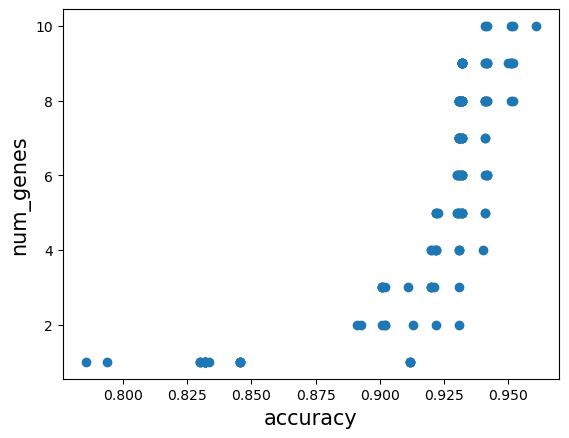

the best one is: accuracy is  0.9609090909090909 , num of genes is  10
selected genes are:  ['ASCL2' 'BLCAP' 'BIVM-ERCC5 ' 'C1QL1' 'APLP1' 'AMD1' 'ANKHD1 ' 'BRAP'
 'ARHGAP26' 'ARHGDIB']
the best one of generation 0 is: accuracy is  0.8718181818181818 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 9 is: accurac

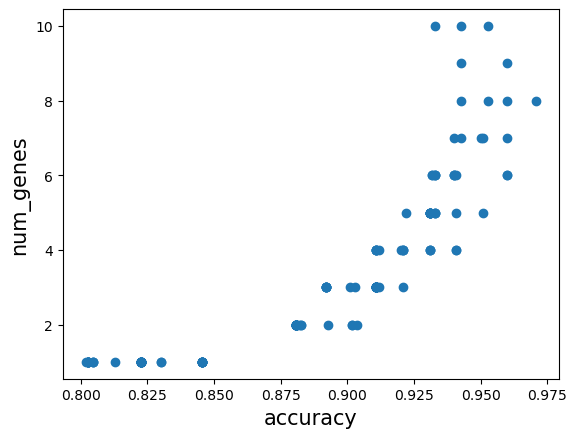

the best one is: accuracy is  0.9709090909090909 , num of genes is  8
selected genes are:  ['ARHGAP1' 'C14orf132' 'ADARB1' 'CAPN15' 'CACNA2D1' 'ABLIM3' 'ATN1' 'CHGA']
the best one of generation 0 is: accuracy is  0.8818181818181818 , num of genes is  6
the best one of generation 1 is: accuracy is  0.8927272727272728 , num of genes is  3
the best one of generation 2 is: accuracy is  0.8927272727272728 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8927272727272728 , num of genes is  3
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9209090909090909 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9209090909090909 , num of genes is  5
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  4
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  4
the best one of generation 9 is: accuracy is  0.94090909090909

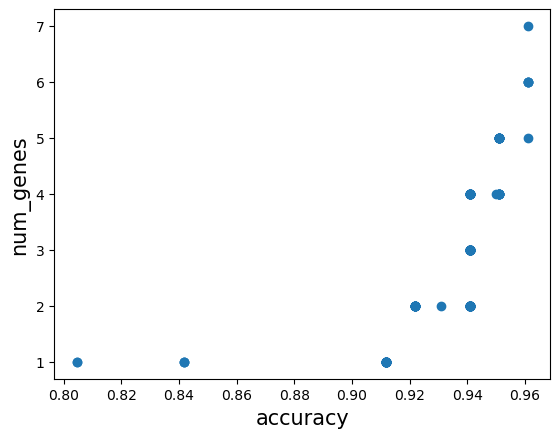

the best one is: accuracy is  0.9609090909090909 , num of genes is  5
selected genes are:  ['ACTL6B' 'BZW1' 'CCL20' 'ANXA8 ' 'ABTB2']
the best one of generation 0 is: accuracy is  0.9209090909090909 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9209090909090909 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9209090909090909 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9209090909090909 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  10
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9318181818181819 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9318181818181819 , num of genes is  10
th

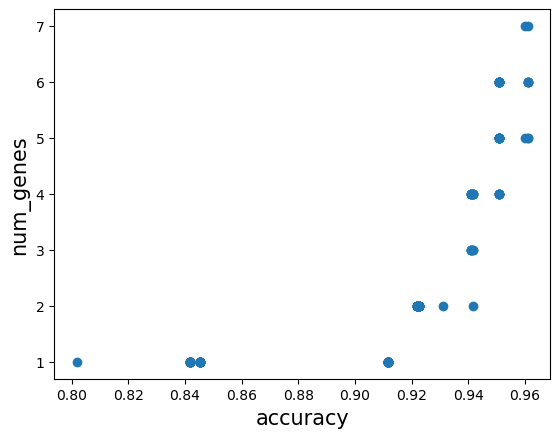

the best one is: accuracy is  0.9609090909090909 , num of genes is  5
selected genes are:  ['ARPC3' 'BAP1' 'ARHGEF16' 'BC069792 ' 'ADK']
the best one of generation 0 is: accuracy is  0.8818181818181818 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9027272727272727 , num of genes is  6
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of genes is  10
the

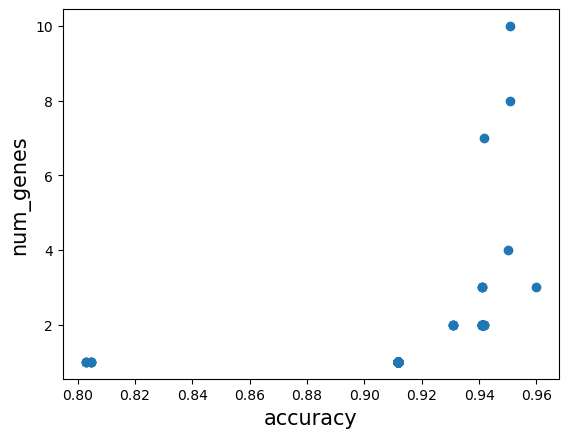

the best one is: accuracy is  0.96 , num of genes is  3
selected genes are:  ['ARPC3' 'ABCA6' 'BTRC']
the best one of generation 0 is: accuracy is  0.9027272727272729 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9027272727272729 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9027272727272729 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9127272727272728 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 10 is: accu

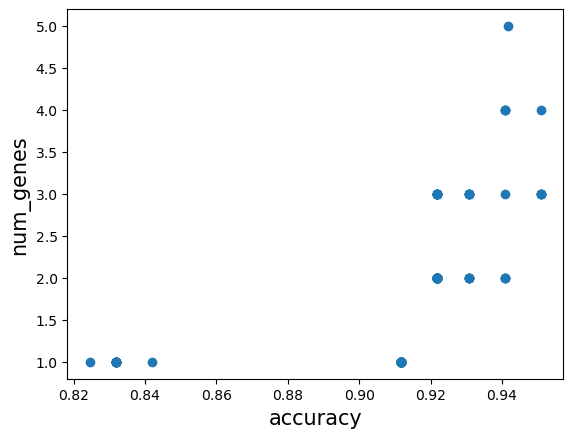

the best one is: accuracy is  0.9509090909090909 , num of genes is  3
selected genes are:  ['ARPC3' 'CBLB' 'CDK8']
the best one of generation 0 is: accuracy is  0.8727272727272728 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8927272727272728 , num of genes is  10
the best one of generation 2 is: accuracy is  0.8927272727272728 , num of genes is  10
the best one of generation 3 is: accuracy is  0.900909090909091 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9318181818181819 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9509090909090909 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of genes is  5
the best one of generat

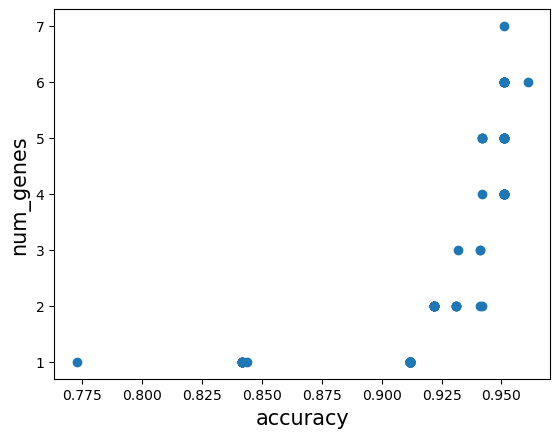

the best one is: accuracy is  0.9609090909090909 , num of genes is  6
selected genes are:  ['CCNC' 'AES' 'CCNE2' 'ANXA2' 'ADAM20' 'CCL14 ']
the best one of generation 0 is: accuracy is  0.8818181818181818 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8818181818181818 , num of genes is  9
the best one of generation 2 is: accuracy is  0.890909090909091 , num of genes is  7
the best one of generation 3 is: accuracy is  0.890909090909091 , num of genes is  7
the best one of generation 4 is: accuracy is  0.900909090909091 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9118181818181819 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9118181818181819 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9118181818181819 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9209090909090909 , num of genes is  10
th

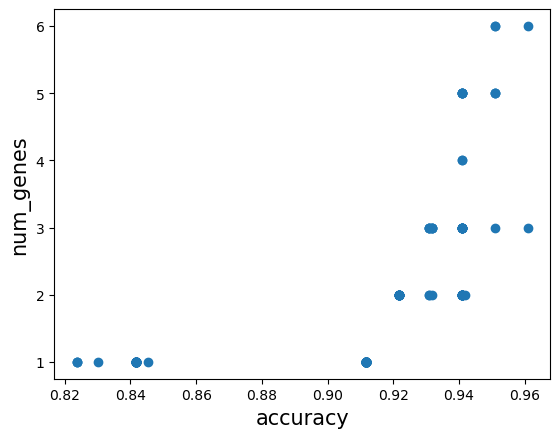

the best one is: accuracy is  0.9609090909090909 , num of genes is  3
selected genes are:  ['ACTL6B' 'ANXA8 ' 'AP2S1']
the best one of generation 0 is: accuracy is  0.8718181818181818 , num of genes is  7
the best one of generation 1 is: accuracy is  0.8718181818181818 , num of genes is  7
the best one of generation 2 is: accuracy is  0.8809090909090909 , num of genes is  10
the best one of generation 3 is: accuracy is  0.900909090909091 , num of genes is  10
the best one of generation 4 is: accuracy is  0.900909090909091 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9118181818181819 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9118181818181819 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9118181818181819 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of 

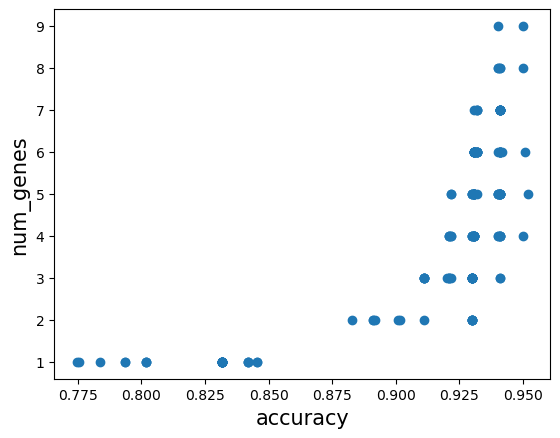

the best one is: accuracy is  0.9518181818181818 , num of genes is  5
selected genes are:  ['ADAM20' 'CBX6' 'BAP1' 'CAMP' 'ATP9B']
the best one of generation 0 is: accuracy is  0.8818181818181818 , num of genes is  7
the best one of generation 1 is: accuracy is  0.8918181818181818 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 6 is: accuracy is  0.93 , num of genes is  9
the best one of generation 7 is: accuracy is  0.93 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9318181818181819 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9318181818181819 , num of genes is  6
the best one of generation 10 is: acc

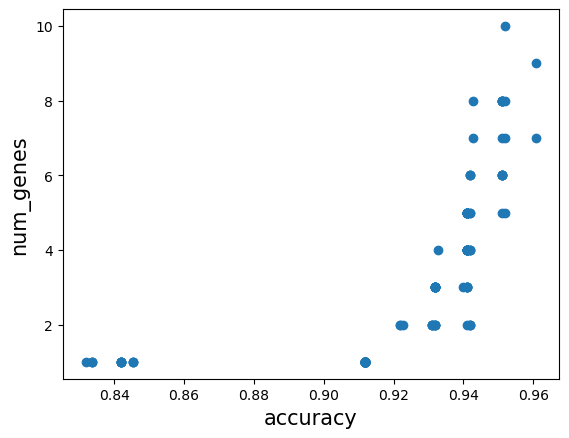

the best one is: accuracy is  0.9609090909090909 , num of genes is  7
selected genes are:  ['CACNA1D' 'CHGA' 'ARPC3' 'ARHGEF2' 'ALOX15' 'CD48' 'ARAP1']
the best one of generation 0 is: accuracy is  0.8936363636363638 , num of genes is  6
the best one of generation 1 is: accuracy is  0.9309090909090909 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9309090909090909 , num of genes is  4
the best one of generation 3 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 4 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 9 is: accuracy is  0.930909090909091 , num of genes i

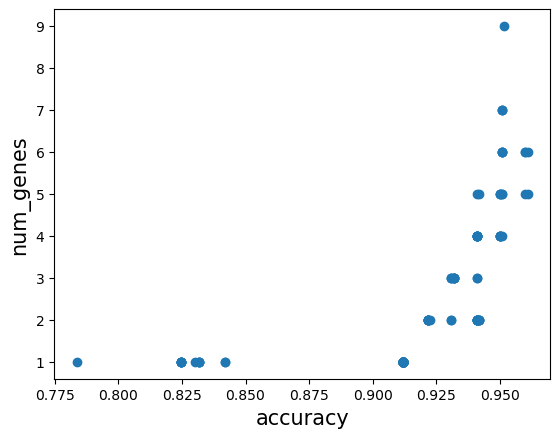

the best one is: accuracy is  0.9609090909090909 , num of genes is  5
selected genes are:  ['CCDC22' 'BLVRB' 'BTRC' 'CD70' 'CDK16']
the best one of generation 0 is: accuracy is  0.8818181818181818 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9118181818181817 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9118181818181817 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9118181818181817 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9118181818181817 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9118181818181817 , num of genes is  7
the best one of generation 6 is: accuracy is  0.95 , num of genes is  6
the best one of generation 7 is: accuracy is  0.95 , num of genes is  6
the best one of generation 8 is: accuracy is  0.95 , num of genes is  6
the best one of generation 9 is: accuracy is  0.95 , num of genes is  6
the best one of generation 10 is: accuracy is  0.950909090909090

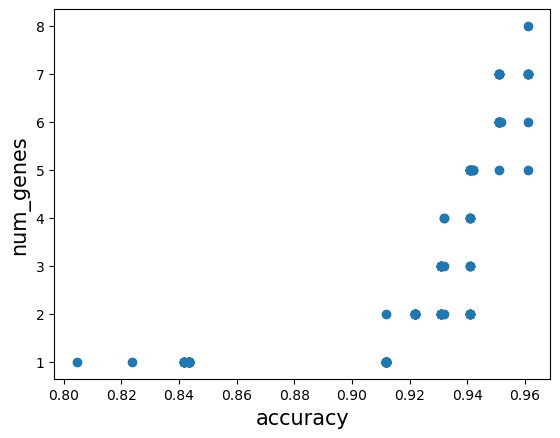

the best one is: accuracy is  0.9609090909090909 , num of genes is  5
selected genes are:  ['CDH22' 'BC069792 ' 'AOC1' 'ART3' 'ARPC3']
the best one of generation 0 is: accuracy is  0.8827272727272728 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9418181818181818 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9418181818181818 , num of genes is 

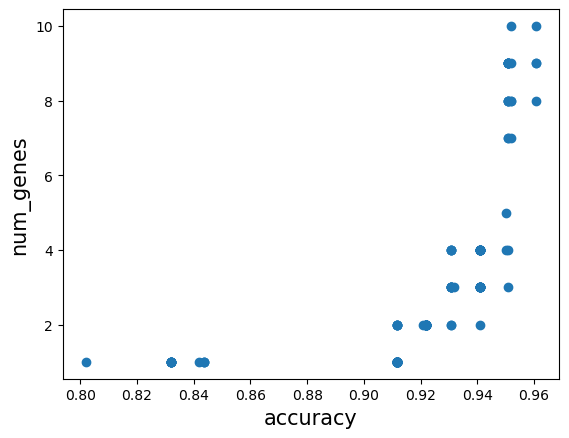

the best one is: accuracy is  0.9609090909090909 , num of genes is  8
selected genes are:  ['ASAP2' 'BAX' 'BAGE' 'BRINP1' 'CDC6' 'AGGF1' 'APBB3 ' 'CAMP']
the best one of generation 0 is: accuracy is  0.890909090909091 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8918181818181818 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9209090909090911 , num of genes is  8
the best one of generation 3 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 4 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  6
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  6
the best one of generation 9 is: accuracy is  0.930909090909091 , num of genes 

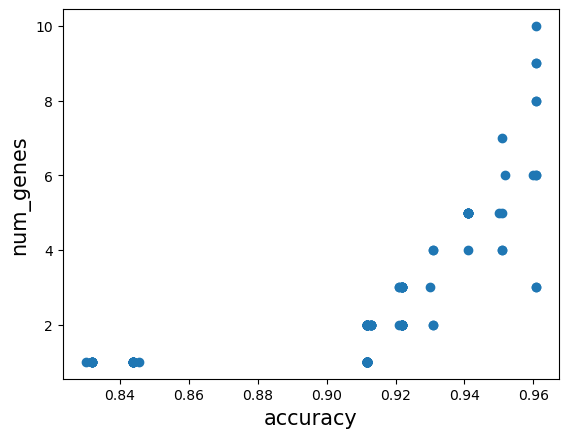

the best one is: accuracy is  0.9609090909090909 , num of genes is  3
selected genes are:  ['ATP6V0C' 'ARPC3' 'BIN1']
the best one of generation 0 is: accuracy is  0.8918181818181818 , num of genes is  6
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  9
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9309090909090909 , num of genes is  8
the best one of generation 6 is: accuracy is  0.940909090909091 , num of genes is  7
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  7
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  7
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  7
the best one of generation 1

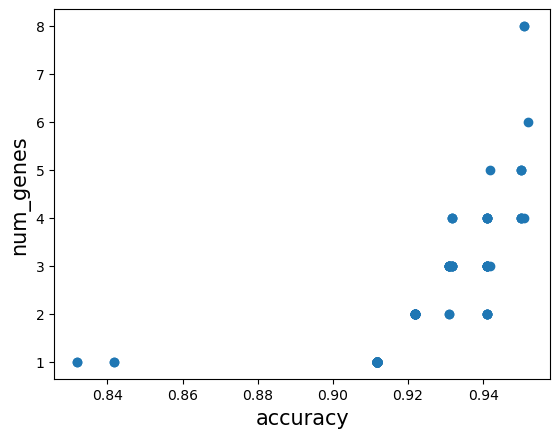

the best one is: accuracy is  0.9518181818181818 , num of genes is  6
selected genes are:  ['BCAR3' 'AOC1' 'B3GAT3' 'CARD10' 'CAMP' 'CASP6']
the best one of generation 0 is: accuracy is  0.9027272727272727 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9027272727272727 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9027272727272727 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9127272727272728 , num of genes is  2
the best one of generation 4 is: accuracy is  0.9127272727272728 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9127272727272728 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9127272727272728 , num of genes is  2
the best one of generation 7 is: accuracy is  0.95 , num of genes is  7
the best one of generation 8 is: accuracy is  0.95 , num of genes is  7
the best one of generation 9 is: accuracy is  0.95 , num of genes is  7
the best one of generation 10 is: accurac

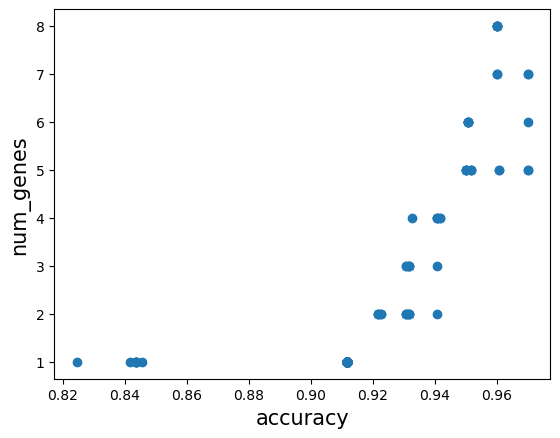

the best one is: accuracy is  0.9700000000000001 , num of genes is  5
selected genes are:  ['ARPC3' 'CACNA1D' 'CCNB1' 'ABCG1' 'AOC1']
the best one of generation 0 is: accuracy is  0.8809090909090911 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8809090909090911 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9109090909090909 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9127272727272728 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9127272727272728 , num of genes is  8
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  9
the best one of generation 9 is: accuracy is  0.930909090909091 , num of genes is  9
the best

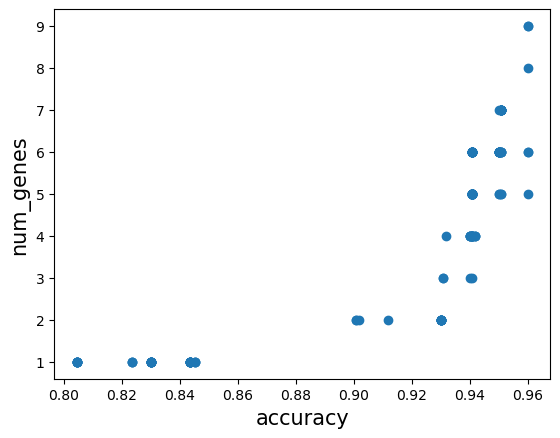

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['ADAM23' 'CAMP' 'BAP1' 'AHCY' 'ACAA1']
the best one of generation 0 is: accuracy is  0.891818181818182 , num of genes is  9
the best one of generation 1 is: accuracy is  0.891818181818182 , num of genes is  9
the best one of generation 2 is: accuracy is  0.891818181818182 , num of genes is  9
the best one of generation 3 is: accuracy is  0.891818181818182 , num of genes is  9
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  9
the best one of generation 5 is: accuracy is  0.901818181818182 , num of genes is  9
the best one of generation 6 is: accuracy is  0.901818181818182 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9109090909090909 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9109090909090909 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 10 

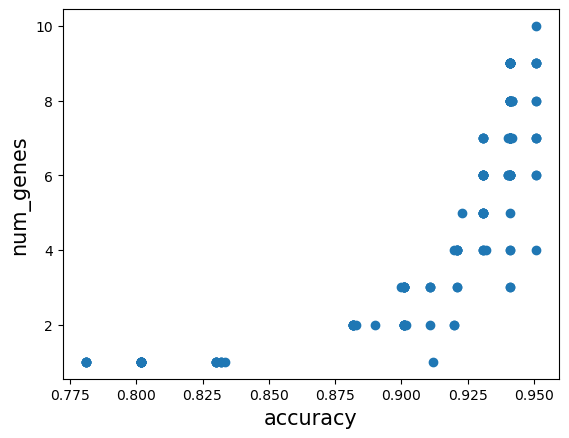

the best one is: accuracy is  0.9509090909090909 , num of genes is  4
selected genes are:  ['CAMP' 'CDK19' 'CCNG1' 'ADCYAP1']
the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  9
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9209090909090909 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9227272727272728 , num of genes is  4
the best one of 

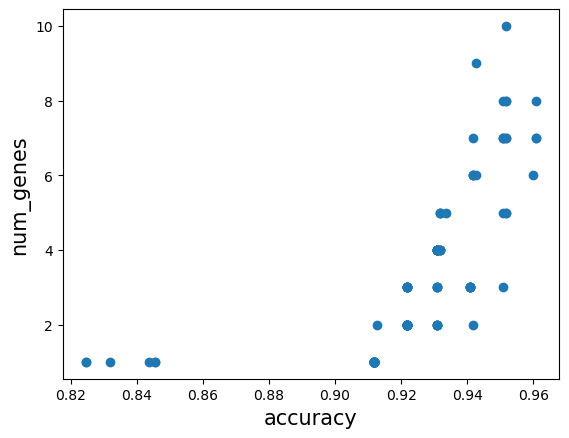

the best one is: accuracy is  0.9609090909090909 , num of genes is  7
selected genes are:  ['AOC1' 'CD4' 'CDC14B' 'ABL1' 'C16orf62' 'ACOT7' 'C11orf58']
the best one of generation 0 is: accuracy is  0.8727272727272727 , num of genes is  8
the best one of generation 1 is: accuracy is  0.8727272727272727 , num of genes is  8
the best one of generation 2 is: accuracy is  0.890909090909091 , num of genes is  9
the best one of generation 3 is: accuracy is  0.890909090909091 , num of genes is  9
the best one of generation 4 is: accuracy is  0.890909090909091 , num of genes is  7
the best one of generation 5 is: accuracy is  0.8927272727272728 , num of genes is  8
the best one of generation 6 is: accuracy is  0.901818181818182 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9209090909090909 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9209090909090909 , num of genes is  6
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes

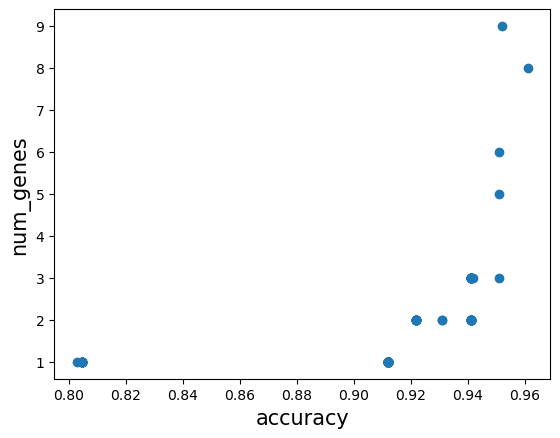

the best one is: accuracy is  0.9609090909090909 , num of genes is  8
selected genes are:  ['BST2' 'AGGF1' 'CCNA1' 'ATRX' 'CEP250' 'CASP6' 'AMACR ' 'CGA']
the best one of generation 0 is: accuracy is  0.890909090909091 , num of genes is  9
the best one of generation 1 is: accuracy is  0.900909090909091 , num of genes is  3
the best one of generation 2 is: accuracy is  0.900909090909091 , num of genes is  3
the best one of generation 3 is: accuracy is  0.940909090909091 , num of genes is  3
the best one of generation 4 is: accuracy is  0.940909090909091 , num of genes is  3
the best one of generation 5 is: accuracy is  0.940909090909091 , num of genes is  3
the best one of generation 6 is: accuracy is  0.940909090909091 , num of genes is  3
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  3
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  3
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes i

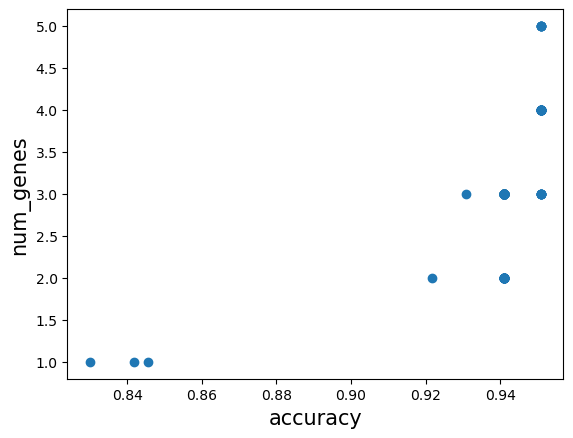

the best one is: accuracy is  0.9509090909090909 , num of genes is  3
selected genes are:  ['CCNG1' 'CAMP' 'AKAP1']
the best one of generation 0 is: accuracy is  0.900909090909091 , num of genes is  9
the best one of generation 1 is: accuracy is  0.900909090909091 , num of genes is  9
the best one of generation 2 is: accuracy is  0.900909090909091 , num of genes is  9
the best one of generation 3 is: accuracy is  0.900909090909091 , num of genes is  9
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9209090909090909 , num of genes is  6
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  6
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  4
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  4
the best one of generation 10 is

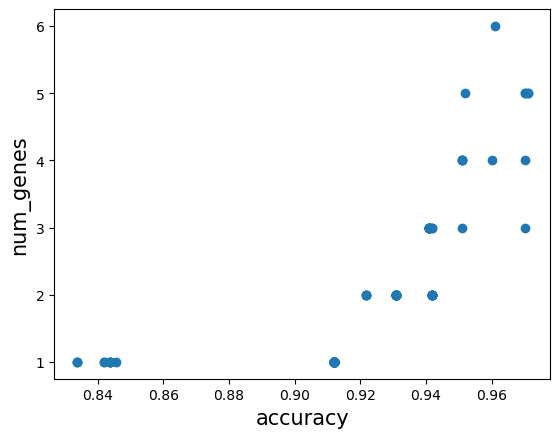

the best one is: accuracy is  0.9709090909090909 , num of genes is  5
selected genes are:  ['CD7' 'ARPC3' 'C11orf80 ' 'CHAF1A' 'CD4']
the best one of generation 0 is: accuracy is  0.900909090909091 , num of genes is  8
the best one of generation 1 is: accuracy is  0.900909090909091 , num of genes is  8
the best one of generation 2 is: accuracy is  0.900909090909091 , num of genes is  8
the best one of generation 3 is: accuracy is  0.900909090909091 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9209090909090909 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9209090909090909 , num of genes is  8
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  10
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  9
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  9
the best one

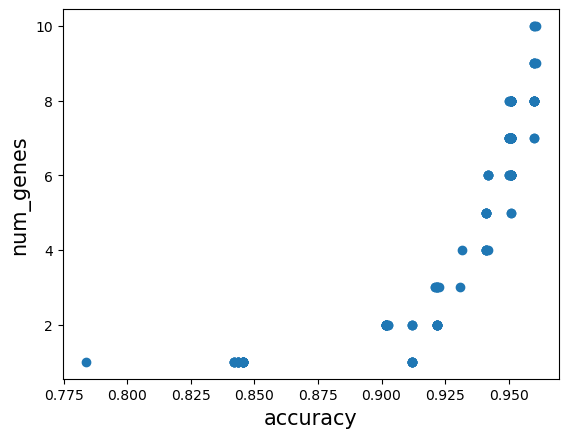

the best one is: accuracy is  0.9609090909090909 , num of genes is  9
selected genes are:  ['CDK12' 'ADAM11' 'ALG3' 'CACNA1D' 'C5' 'AKAP5' 'AP2S1' 'ARPC3' 'ARMCX4']
the best one of generation 0 is: accuracy is  0.9118181818181819 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9118181818181819 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  6
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  9
the best one of generation 9 is: accuracy is  0.93090909090909

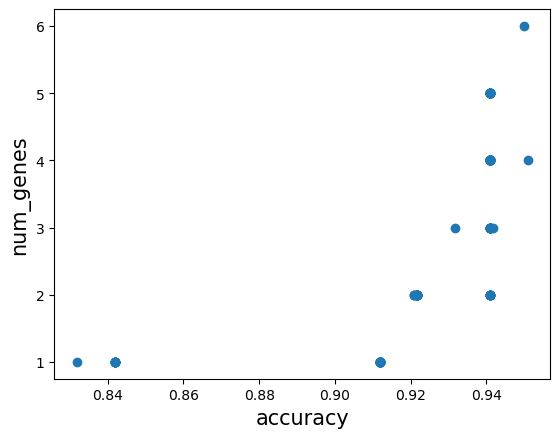

the best one is: accuracy is  0.9509090909090909 , num of genes is  4
selected genes are:  ['ARPC3' 'BZW1' 'CCK' 'ACTC1']
the best one of generation 0 is: accuracy is  0.891818181818182 , num of genes is  7
the best one of generation 1 is: accuracy is  0.891818181818182 , num of genes is  7
the best one of generation 2 is: accuracy is  0.891818181818182 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9027272727272729 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9209090909090911 , num of genes is  3
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  2
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  2
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  2
the best one of generatio

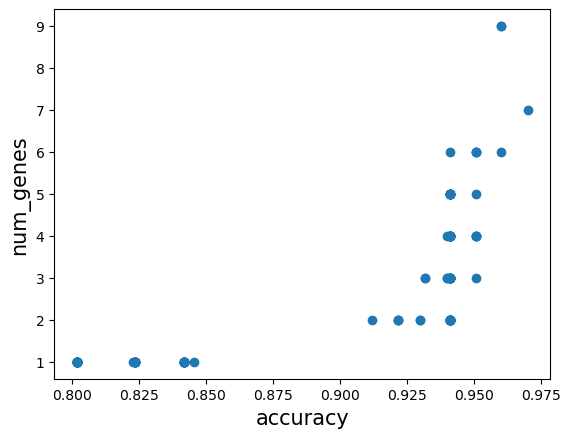

the best one is: accuracy is  0.97 , num of genes is  7
selected genes are:  ['ABCG2' 'CAMP' 'ATAD2B' 'AHDC1' 'ALDH1L1' 'CD4' 'ALDOC']


In [9]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=10,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  11
the best one of generation 1 is: accuracy is  0.9109090909090909 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  15
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  10
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  9
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  9
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  9
the best one of generation 10 is: accuracy is  0.940909090909091 , num of genes is  9
the best one of generation 11 is: accuracy is  0.94

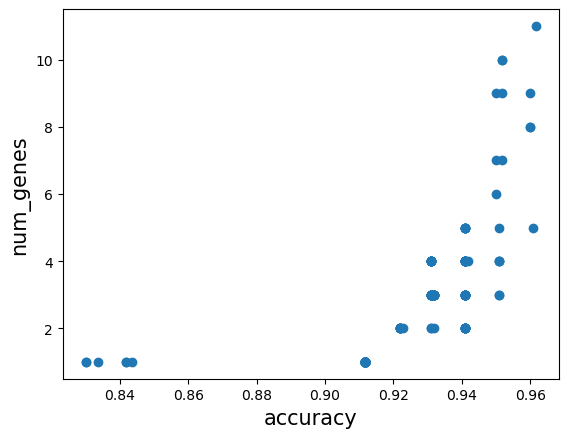

the best one is: accuracy is  0.9618181818181817 , num of genes is  11
selected genes are:  ['CALR' 'AP3B1' 'AGPS' 'CACNA1S' 'CCNG1' 'ALDOA' 'CCNI' 'ACYP2 ' 'CCNB2'
 'CDK20' 'APBA2']
the best one of generation 0 is: accuracy is  0.8818181818181818 , num of genes is  14
the best one of generation 1 is: accuracy is  0.8909090909090909 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9209090909090909 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9209090909090909 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9209090909090909 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  11
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 9 is: accur

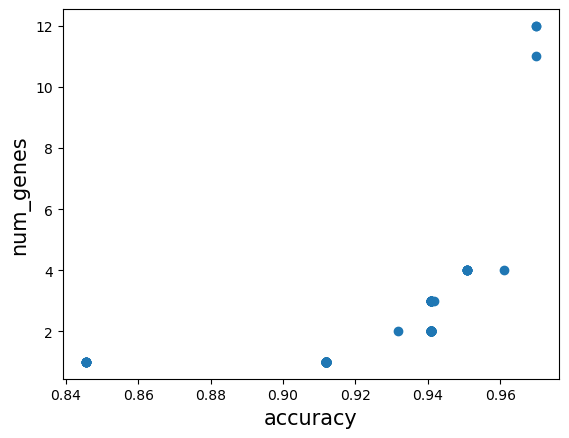

the best one is: accuracy is  0.9700000000000001 , num of genes is  11
selected genes are:  ['CCNG1' 'ABCG1' 'ATP8A2' 'AMPD3' 'ARFRP1' 'ARF3' 'ACADL' 'ATP5G3' 'CDHR1'
 'CAMP' 'CEACAM6']
the best one of generation 0 is: accuracy is  0.9218181818181819 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9218181818181819 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9218181818181819 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9218181818181819 , num of genes is  13
the best one of generation 4 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 5 is: accuracy is  0.940909090909091 , num of genes is  12
the best one of generation 6 is: accuracy is  0.940909090909091 , num of genes is  12
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  12
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  12
the best one of generation 9 is: acc

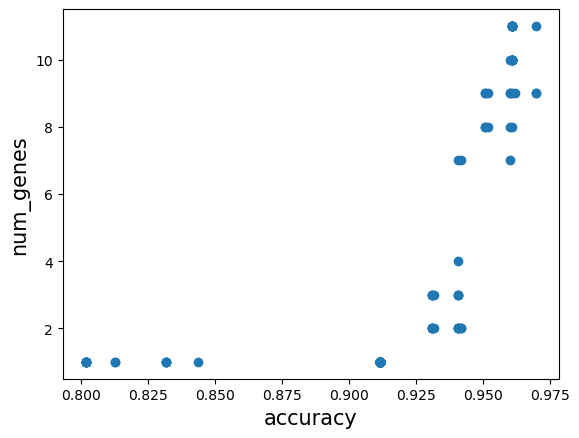

the best one is: accuracy is  0.97 , num of genes is  9
selected genes are:  ['BAI2' 'ARPC3' 'CD36' 'AVP' 'CDK2AP2' 'CCNB1' 'CACNA1S' 'AJ004954 ' 'AGA']
the best one of generation 0 is: accuracy is  0.890909090909091 , num of genes is  15
the best one of generation 1 is: accuracy is  0.890909090909091 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  15
the best one of generation 3 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  9
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9509090909090909 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9609090909090909 , num of genes is  15
the best one of generation 9 is: accuracy is  0.9609090909090909 , num of

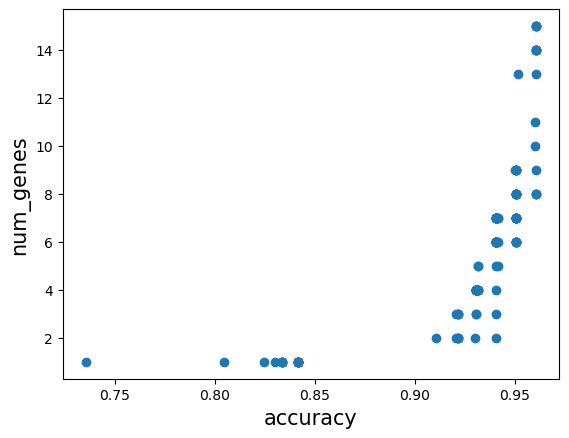

the best one is: accuracy is  0.9609090909090909 , num of genes is  8
selected genes are:  ['ALDH1A3' 'C2orf27A ' 'B3GAT2' 'ATP8A1' 'BMI1 ' 'ADAM8' 'CDC20' 'CAMP']
the best one of generation 0 is: accuracy is  0.9100000000000001 , num of genes is  14
the best one of generation 1 is: accuracy is  0.9100000000000001 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9100000000000001 , num of genes is  14
the best one of generation 3 is: accuracy is  0.9200000000000002 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9200000000000002 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  13
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  5
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  15
the best one of generation 9 is: accuracy is  0.940000000

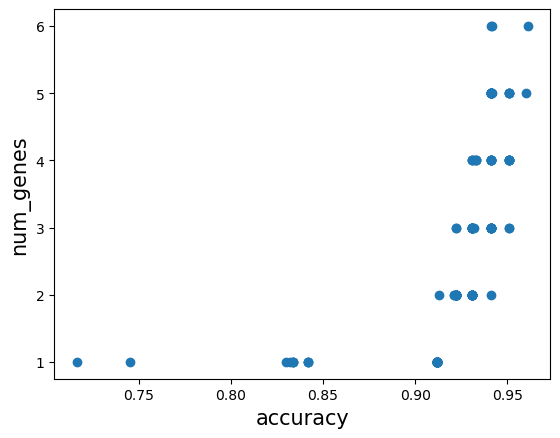

the best one is: accuracy is  0.9609090909090909 , num of genes is  6
selected genes are:  ['CCDC85B' 'CCNE1' 'AES' 'ARPC3' 'B9D1' 'CBFA2T3']
the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  5
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  5
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9309090909090909 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9318181818181819 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9318181818181819 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9318181818181819 , num of genes is  

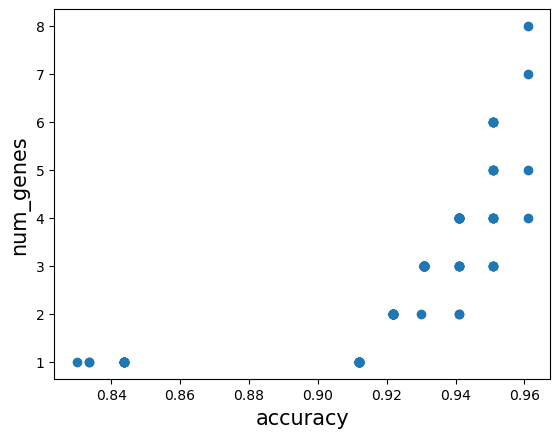

the best one is: accuracy is  0.9609090909090909 , num of genes is  4
selected genes are:  ['ARPC3' 'CAMP' 'CASP6' 'C11orf80 ']
the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  13
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9209090909090911 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  14
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  10
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of genes is  13
the bes

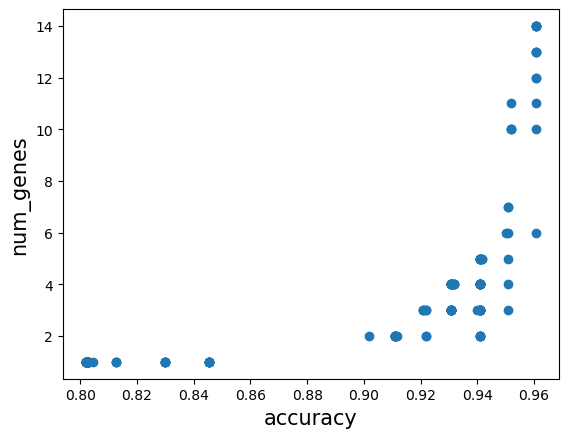

the best one is: accuracy is  0.9609090909090909 , num of genes is  6
selected genes are:  ['ATP11A' 'CDC42EP2' 'CACNA1D' 'AL928768.3 ' 'BAP1' 'ATXN2']
the best one of generation 0 is: accuracy is  0.9118181818181819 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9118181818181819 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9209090909090909 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9209090909090909 , num of genes is  7
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  5
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  5
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9509090909090909 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of

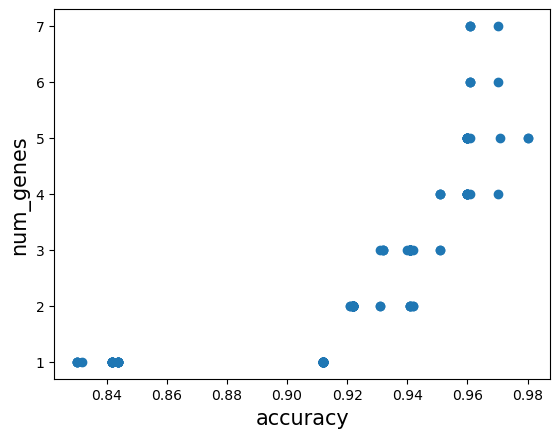

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['ABTB2' 'ARPC3' 'CD4' 'AMIGO2' 'ATXN2']
the best one of generation 0 is: accuracy is  0.9100000000000001 , num of genes is  7
the best one of generation 1 is: accuracy is  0.93 , num of genes is  8
the best one of generation 2 is: accuracy is  0.93 , num of genes is  8
the best one of generation 3 is: accuracy is  0.93 , num of genes is  8
the best one of generation 4 is: accuracy is  0.93 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 6 is: accuracy is  0.95 , num of genes is  8
the best one of generation 7 is: accuracy is  0.95 , num of genes is  8
the best one of generation 8 is: accuracy is  0.95 , num of genes is  8
the best one of generation 9 is: accuracy is  0.95 , num of genes is  8
the best one of generation 10 is: accuracy is  0.95 , num of genes is  8
the best one of generation 11 is: accuracy is  

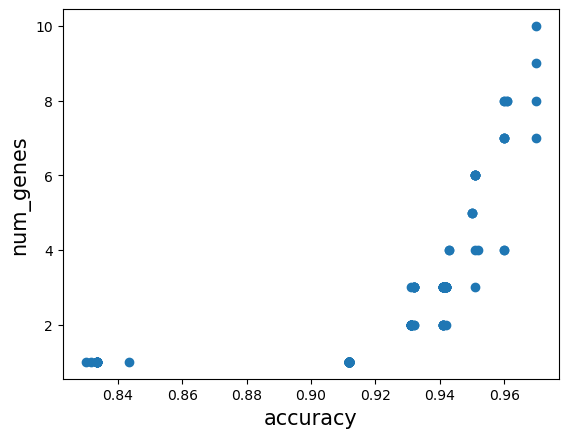

the best one is: accuracy is  0.97 , num of genes is  7
selected genes are:  ['BIK' 'CD70' 'CAMLG' 'CEL ' 'CACNA1D' 'CDC42EP2' 'CCNA1']
the best one of generation 0 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 1 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 2 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 3 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 4 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  13
the best one of generation 6 is: accuracy is  0.940909090909091 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9509090909090909 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9509090909090909 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of genes is  10
t

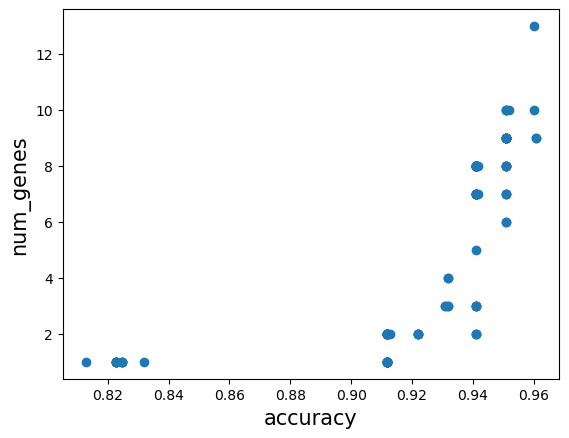

the best one is: accuracy is  0.9609090909090909 , num of genes is  9
selected genes are:  ['ANKRD40' 'CCHCR1' 'ARFGAP2' 'CCL11' 'CALU' 'CCNG1' 'B2M' 'BNIP3L'
 'ALDH2']
the best one of generation 0 is: accuracy is  0.891818181818182 , num of genes is  2
the best one of generation 1 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 4 is: accuracy is  0.9209090909090909 , num of genes is  11
the best one of generation 5 is: accuracy is  0.940909090909091 , num of genes is  11
the best one of generation 6 is: accuracy is  0.9609090909090909 , num of genes is  11
the best one of generation 7 is: accuracy is  0.9609090909090909 , num of genes is  11
the best one of generation 8 is: accuracy is  0.9709090909090909 , num of genes is  11
the best one of generation 9 is: accuracy is  0.970909

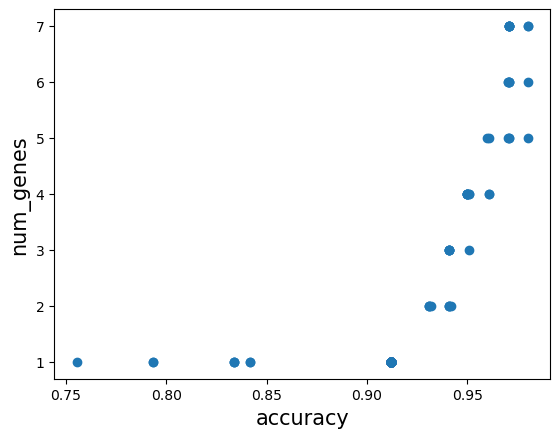

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['APPBP2' 'ABTB2' 'ADRB3' 'CAMP' 'CCDC22']
the best one of generation 0 is: accuracy is  0.9109090909090909 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9109090909090909 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  11
the best one of generation 3 is: accuracy is  0.9209090909090909 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9209090909090911 , num of genes is  10
the best one of generation 5 is: accuracy is  0.93 , num of genes is  10
the best one of generation 6 is: accuracy is  0.93 , num of genes is  10
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  10
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  9
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  9
the best one of generation 10

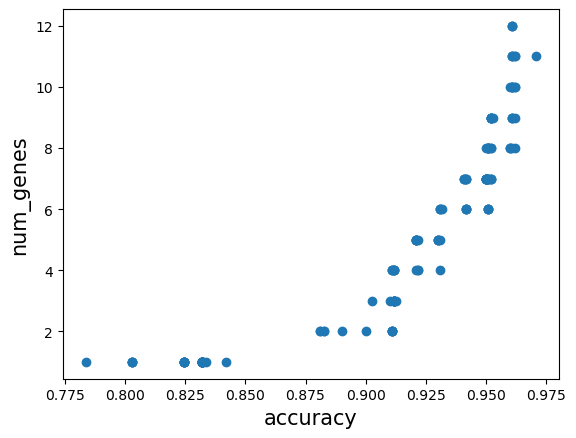

the best one is: accuracy is  0.9709090909090909 , num of genes is  11
selected genes are:  ['CACNA1D' 'ATP8A1' 'CACNA2D1' 'C21orf33' 'CELSR1' 'CEACAM1' 'C19orf10'
 'C3orf62 ' 'CETN2' 'AQP8' 'ASGR1']
the best one of generation 0 is: accuracy is  0.900909090909091 , num of genes is  14
the best one of generation 1 is: accuracy is  0.900909090909091 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  15
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9109090909090909 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9209090909090909 , num of genes is  14
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  4
the best one of gene

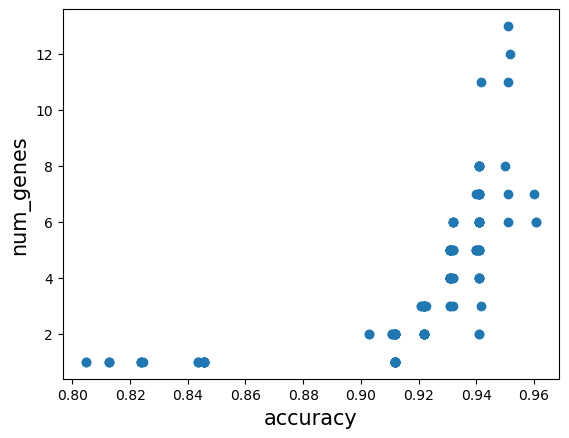

the best one is: accuracy is  0.9609090909090909 , num of genes is  6
selected genes are:  ['C19orf26' 'ARPC3' 'AIPL1' 'BMP6' 'CD4' 'ANXA8 ']
the best one of generation 0 is: accuracy is  0.8827272727272728 , num of genes is  14
the best one of generation 1 is: accuracy is  0.8827272727272728 , num of genes is  14
the best one of generation 2 is: accuracy is  0.900909090909091 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9127272727272728 , num of genes is  13
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  5
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  5
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9309090909090909 , num of genes is  4

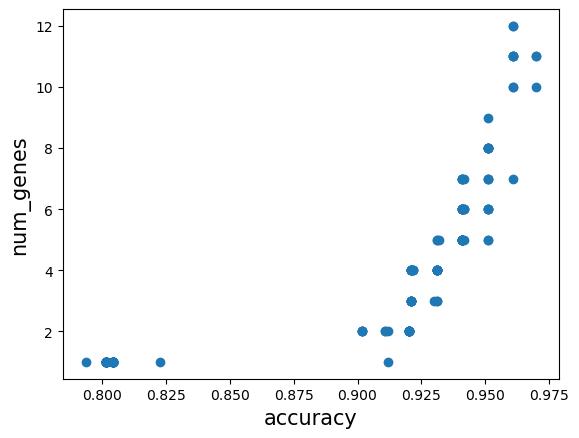

the best one is: accuracy is  0.97 , num of genes is  10
selected genes are:  ['ATP5G2' 'ARPC3' 'BAP1' 'CDYL' 'ADRA2C' 'AHSA1' 'BLMH' 'CHD9' 'CD2'
 'CENPA ']
the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  11
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  11
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  11
the best one of generation 3 is: accuracy is  0.901818181818182 , num of genes is  11
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9109090909090909 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9227272727272728 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9227272727272728 , num of genes is  10
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9400000000000001 , n

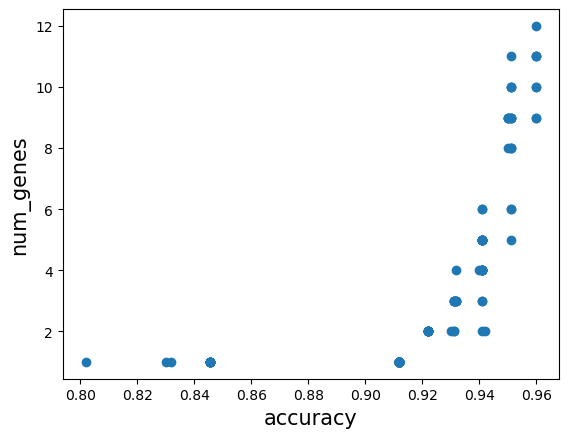

the best one is: accuracy is  0.96 , num of genes is  9
selected genes are:  ['ATF7' 'AGRN' 'ABCF3' 'AHNAK2' 'ALB' 'CEACAM7' 'ARPC3' 'CDC27' 'ARHGAP33']
the best one of generation 0 is: accuracy is  0.900909090909091 , num of genes is  15
the best one of generation 1 is: accuracy is  0.900909090909091 , num of genes is  15
the best one of generation 2 is: accuracy is  0.900909090909091 , num of genes is  15
the best one of generation 3 is: accuracy is  0.900909090909091 , num of genes is  14
the best one of generation 4 is: accuracy is  0.900909090909091 , num of genes is  14
the best one of generation 5 is: accuracy is  0.900909090909091 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9109090909090909 , num of genes is  15
the best one of generation 7 is: accuracy is  0.9109090909090911 , num of genes is  13
the best one of generation 8 is: accuracy is  0.9109090909090911 , num of genes is  13
the best one of generation 9 is: accuracy is  0.9209090909090909 , num

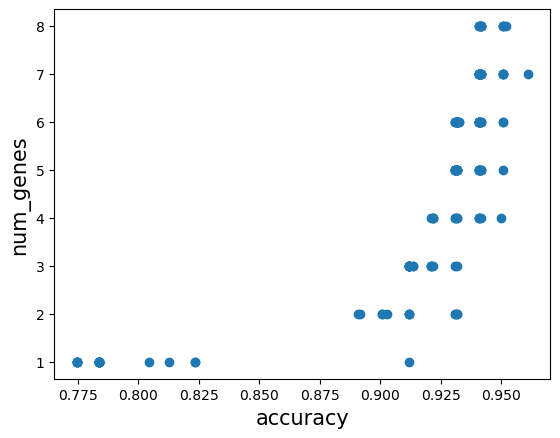

the best one is: accuracy is  0.9609090909090909 , num of genes is  7
selected genes are:  ['B3GALT5' 'ARPP19' 'C2CD3' 'CACNA1D' 'ARPC3' 'ALDOA' 'ADRB3']
the best one of generation 0 is: accuracy is  0.8818181818181818 , num of genes is  14
the best one of generation 1 is: accuracy is  0.9218181818181819 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9218181818181819 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9218181818181819 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 9 is: accuracy is  0.930909090909091 , num of 

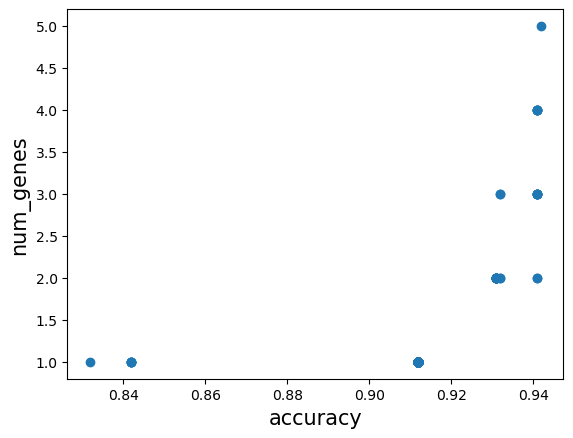

the best one is: accuracy is  0.941818181818182 , num of genes is  5
selected genes are:  ['CDK2AP2' 'ARPC3' 'CAV3' 'CDK8' 'ADCYAP1R1']
the best one of generation 0 is: accuracy is  0.9209090909090909 , num of genes is  11
the best one of generation 1 is: accuracy is  0.930909090909091 , num of genes is  11
the best one of generation 2 is: accuracy is  0.930909090909091 , num of genes is  11
the best one of generation 3 is: accuracy is  0.930909090909091 , num of genes is  11
the best one of generation 4 is: accuracy is  0.930909090909091 , num of genes is  10
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  10
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  10
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9509090909090909 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of genes is  4
the 

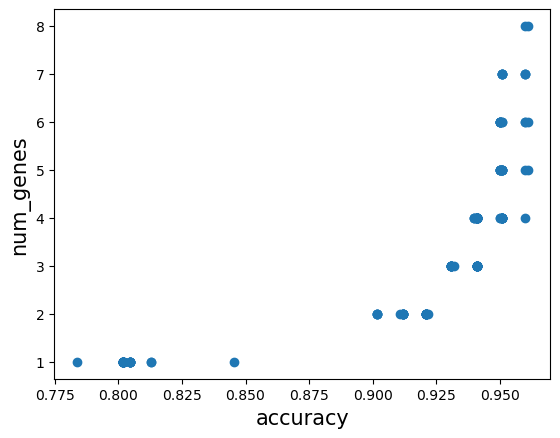

the best one is: accuracy is  0.9609090909090909 , num of genes is  5
selected genes are:  ['CDH19' 'CAMP' 'ABTB2' 'ART4' 'CDC42BPA']
the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  13
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9200000000000002 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9200000000000002 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9209090909090909 , num of genes is  9
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9309090909090909 , num of genes is  6
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of genes is  9
the b

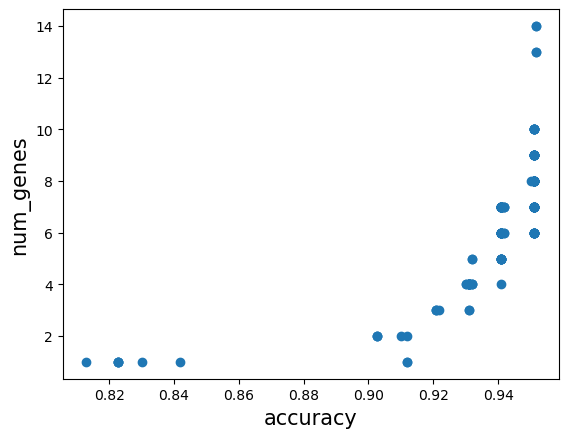

the best one is: accuracy is  0.9518181818181818 , num of genes is  13
selected genes are:  ['ANK2' 'ASIC2' 'AV8S2 ' 'ANK1' 'AAK1' 'CD160' 'CCL22' 'ADH7' 'AMMECR1'
 'CD28' 'CBX7' 'CAMP' 'ANAPC15']
the best one of generation 0 is: accuracy is  0.9209090909090909 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9209090909090909 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9209090909090909 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9209090909090909 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9209090909090909 , num of genes is  12
the best one of generation 5 is: accuracy is  0.9209090909090909 , num of genes is  12
the best one of generation 6 is: accuracy is  0.9209090909090909 , num of genes is  12
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  15
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of genera

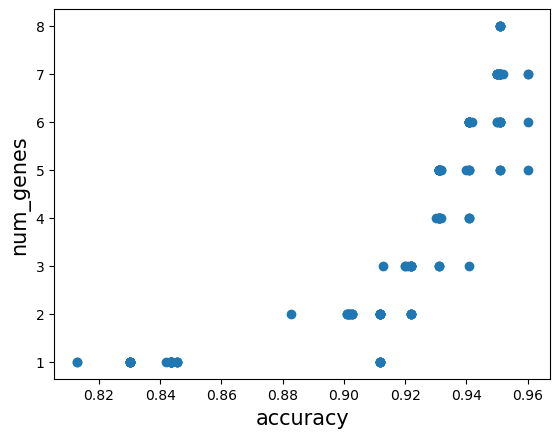

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['APOB' 'ABCG2' 'CACNA1S' 'CAPNS1' 'ARPC3']
the best one of generation 0 is: accuracy is  0.9209090909090909 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9209090909090909 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9209090909090909 , num of genes is  14
the best one of generation 3 is: accuracy is  0.940909090909091 , num of genes is  13
the best one of generation 4 is: accuracy is  0.940909090909091 , num of genes is  13
the best one of generation 5 is: accuracy is  0.940909090909091 , num of genes is  6
the best one of generation 6 is: accuracy is  0.940909090909091 , num of genes is  6
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  6
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  6
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  6
the best one of gener

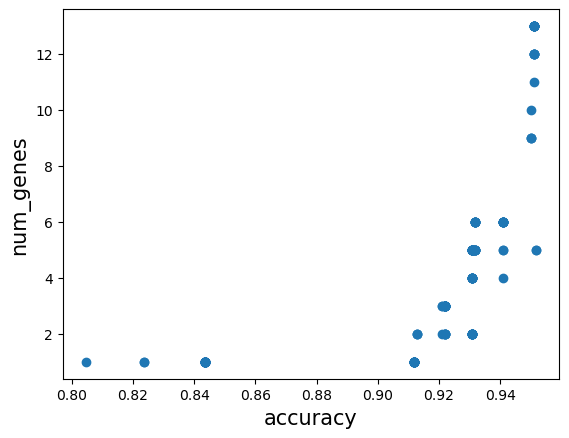

the best one is: accuracy is  0.9518181818181818 , num of genes is  5
selected genes are:  ['CAPNS1' 'CBFB' 'AES' 'ALPL' 'CADM1']
the best one of generation 0 is: accuracy is  0.900909090909091 , num of genes is  10
the best one of generation 1 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 2 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 3 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 4 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9318181818181819 , num of genes is  15
the best one of generation 7 is: accuracy is  0.9318181818181819 , num of genes is  10
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  10
the best one of generation 9 is: accuracy is  0.95 , num of genes is  5
the best one of generation 

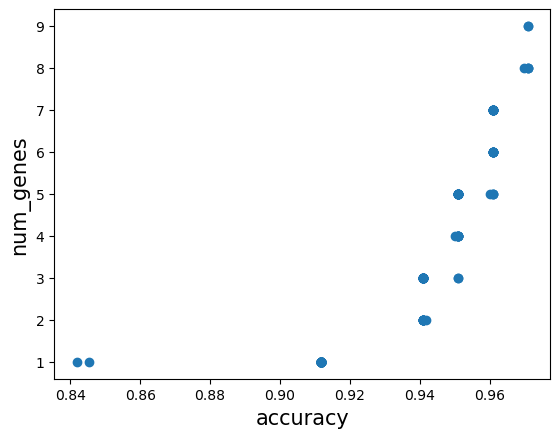

the best one is: accuracy is  0.9709090909090909 , num of genes is  8
selected genes are:  ['ATG5' 'CAMP' 'CD96' 'BEST1' 'CCNG1' 'ANKRD40' 'ADH1C' 'ASGR1']
the best one of generation 0 is: accuracy is  0.890909090909091 , num of genes is  14
the best one of generation 1 is: accuracy is  0.9227272727272726 , num of genes is  15
the best one of generation 2 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 3 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 4 is: accuracy is  0.930909090909091 , num of genes is  14
the best one of generation 5 is: accuracy is  0.940909090909091 , num of genes is  13
the best one of generation 6 is: accuracy is  0.940909090909091 , num of genes is  12
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  12
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  12
the best one of generation 9 is: accuracy is  0.9509090909090909 , nu

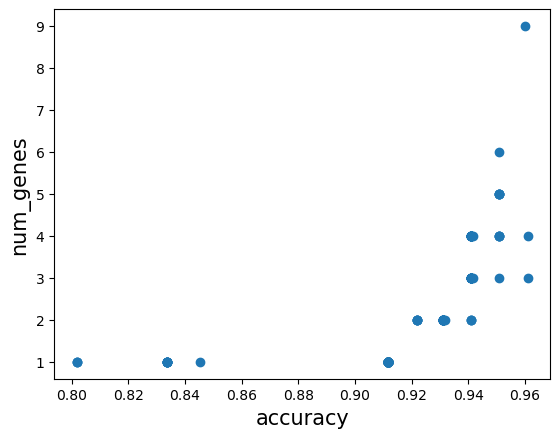

the best one is: accuracy is  0.9609090909090909 , num of genes is  3
selected genes are:  ['ARPC3' 'ARHGAP11A' 'CDK7']
the best one of generation 0 is: accuracy is  0.8736363636363638 , num of genes is  7
the best one of generation 1 is: accuracy is  0.891818181818182 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9027272727272727 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9027272727272727 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9099999999999999 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9099999999999999 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9118181818181819 , num of genes is  14
the best one of generation 7 is: accuracy is  0.9209090909090909 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9318181818181819 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9318181818181819 , num of genes is  7
the best one of g

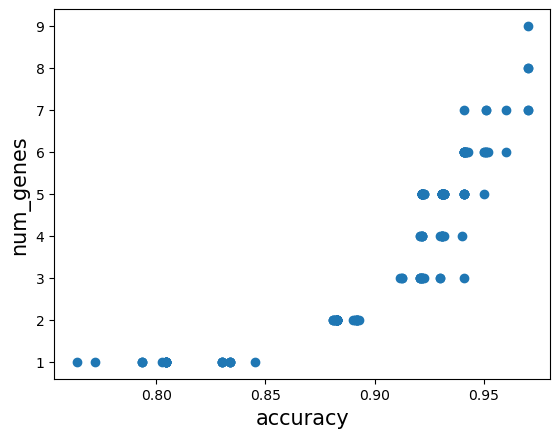

the best one is: accuracy is  0.97 , num of genes is  7
selected genes are:  ['ATP6V0A1' 'AIM2' 'ACADL' 'CBLB' 'AES' 'CDK8' 'BANF1']
the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  15
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  15
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  15
the best one of generation 3 is: accuracy is  0.901818181818182 , num of genes is  15
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  13
the best one of generation 5 is: accuracy is  0.930909090909091 , num of genes is  13
the best one of generation 6 is: accuracy is  0.930909090909091 , num of genes is  13
the best one of generation 7 is: accuracy is  0.930909090909091 , num of genes is  13
the best one of generation 8 is: accuracy is  0.930909090909091 , num of genes is  13
the best one of generation 9 is: accuracy is  0.930909090909091 , num of genes is  13
the be

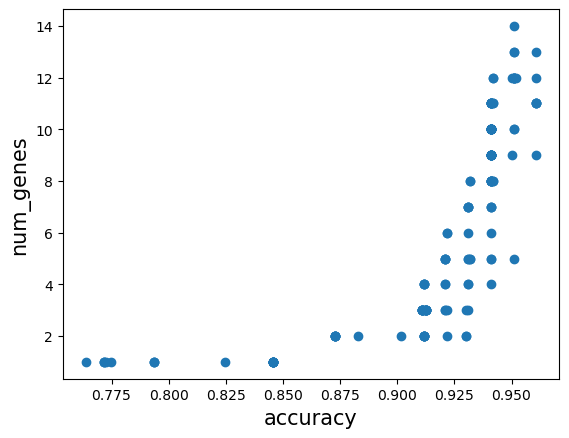

the best one is: accuracy is  0.9609090909090909 , num of genes is  9
selected genes are:  ['AP3M2' 'ATPAF2' 'BYSL' 'BRAP' 'ATRX' 'AKAP13' 'ACOT1 ' 'ANGPTL7' 'CDC7']


In [6]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=15,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.901818181818182 , num of genes is  4
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  4
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9127272727272727 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9127272727272727 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9127272727272727 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9127272727272727 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9127272727272727 , num of genes is  5
the best one of generation 10 is: accuracy is  0.940909090909091 , num of genes is  4
the best one of generation 11 is: accuracy is  0.95090909

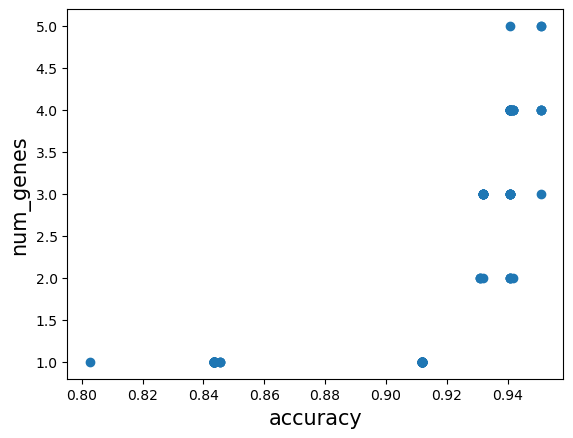

the best one is: accuracy is  0.9509090909090909 , num of genes is  3
selected genes are:  ['ARPC3' 'ARHGAP11A' 'ANK3']
the best one of generation 0 is: accuracy is  0.8427272727272728 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8709090909090911 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8709090909090911 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9109090909090909 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 8 is: accuracy is  0.9309090909090909 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9309090909090909 , num of genes is  5
the best one of gene

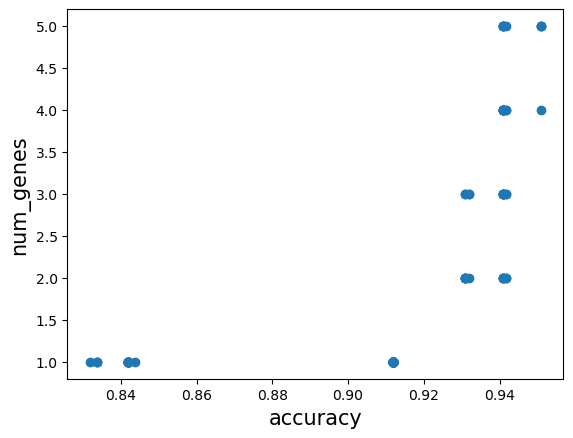

the best one is: accuracy is  0.9509090909090909 , num of genes is  4
selected genes are:  ['ARPC3' 'CD4' 'ACTL8' 'CBX4']
the best one of generation 0 is: accuracy is  0.8718181818181817 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8718181818181817 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8818181818181818 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8818181818181818 , num of genes is  3
the best one of generation 4 is: accuracy is  0.8818181818181818 , num of genes is  3
the best one of generation 5 is: accuracy is  0.8818181818181818 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 7 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 8 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 9 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of ge

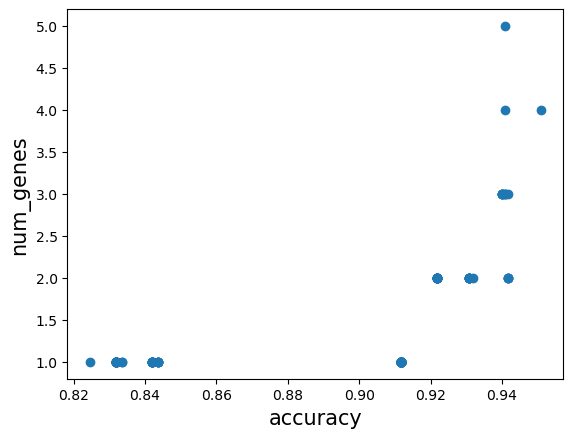

the best one is: accuracy is  0.9509090909090909 , num of genes is  4
selected genes are:  ['ACAP2' 'CAMP' 'CABIN1' 'CEACAM8']
the best one of generation 0 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 1 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  4
the best one o

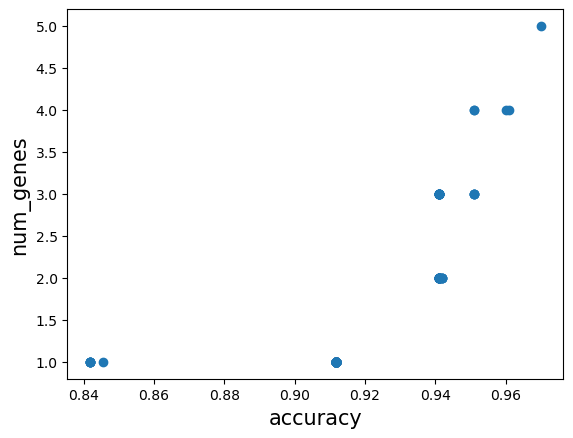

the best one is: accuracy is  0.9700000000000001 , num of genes is  5
selected genes are:  ['ARPC3' 'BLVRB' 'ADIRF' 'CD4' 'BRE']
the best one of generation 0 is: accuracy is  0.8518181818181818 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8818181818181818 , num of genes is  5
the best one of generation 2 is: accuracy is  0.890909090909091 , num of genes is  3
the best one of generation 3 is: accuracy is  0.890909090909091 , num of genes is  3
the best one of generation 4 is: accuracy is  0.900909090909091 , num of genes is  5
the best one of generation 5 is: accuracy is  0.900909090909091 , num of genes is  5
the best one of generation 6 is: accuracy is  0.900909090909091 , num of genes is  5
the best one of generation 7 is: accuracy is  0.901818181818182 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of g

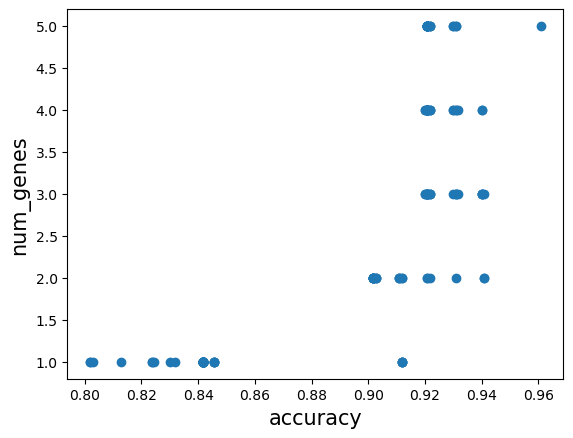

the best one is: accuracy is  0.9609090909090909 , num of genes is  5
selected genes are:  ['ABTB2' 'ARHGEF9' 'BAP1' 'CFHR2' 'ARPC3']
the best one of generation 0 is: accuracy is  0.8336363636363637 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8409090909090908 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8545454545454545 , num of genes is  4
the best one of generation 3 is: accuracy is  0.891818181818182 , num of genes is  4
the best one of generation 4 is: accuracy is  0.891818181818182 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9000000000000001 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9000000000000001 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9000000000000001 , num of genes is  3
the best one of generation 8 is: accuracy is  0.900909090909091 , num of genes is  4
the best one of generation 9 is: accuracy is  0.900909090909091 , num of genes is  4
the best o

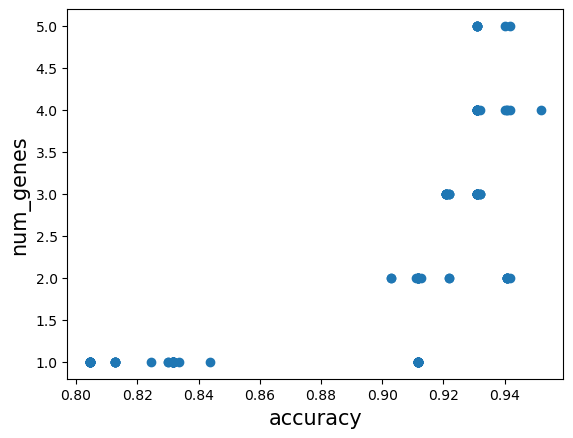

the best one is: accuracy is  0.9518181818181819 , num of genes is  4
selected genes are:  ['ARPC3' 'CD4' 'BCL2L2' 'CACNB4']
the best one of generation 0 is: accuracy is  0.8927272727272728 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8927272727272728 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8927272727272728 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9318181818181819 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9318181818181819 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9318181818181819 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9318181818181819 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of

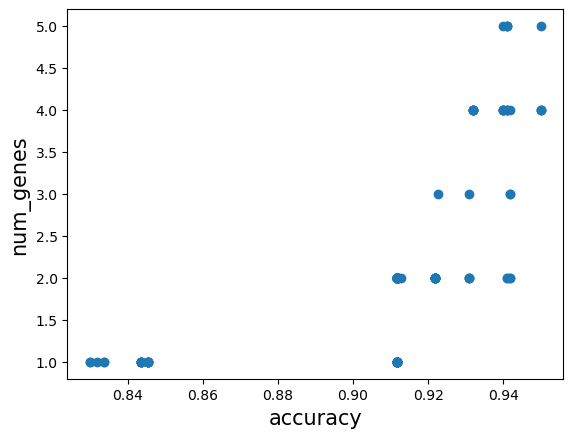

the best one is: accuracy is  0.95 , num of genes is  4
selected genes are:  ['ABTB2' 'AANAT' 'ASMT' 'BAGE']
the best one of generation 0 is: accuracy is  0.8718181818181818 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8718181818181818 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8827272727272728 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8827272727272728 , num of genes is  4
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 5 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9118181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 10 is:

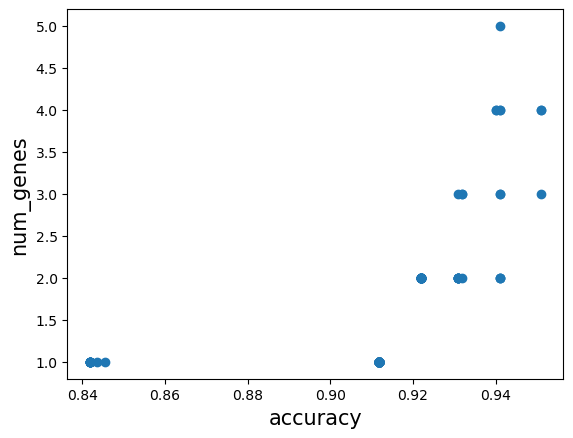

the best one is: accuracy is  0.9509090909090909 , num of genes is  3
selected genes are:  ['ARPC3' 'BPY2' 'CDK8']
the best one of generation 0 is: accuracy is  0.8436363636363635 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8436363636363635 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8918181818181818 , num of genes is  5
the best one of generation 3 is: accuracy is  0.900909090909091 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  4
the best one of generation 9 is: accuracy is  0.930909090909091 , num of genes is  3
the best one of generation 

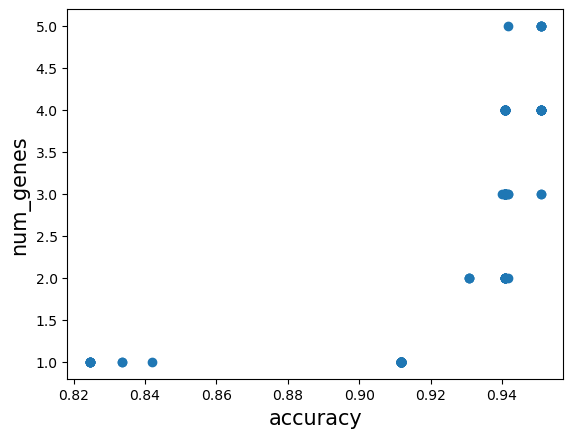

the best one is: accuracy is  0.9509090909090909 , num of genes is  3
selected genes are:  ['ARPC3' 'ABCA6' 'CDC42EP4']
the best one of generation 0 is: accuracy is  0.8699999999999999 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8699999999999999 , num of genes is  5
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 3 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 9 is: accuracy is  0.930909090909091 , num of genes is  4
the best one of generati

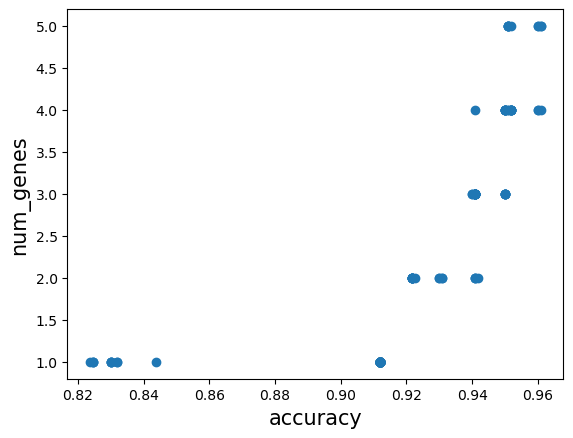

the best one is: accuracy is  0.9609090909090909 , num of genes is  4
selected genes are:  ['CAMP' 'ABTB2' 'ADRB3' 'ATP6V1A']
the best one of generation 0 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 1 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 2 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 3 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one o

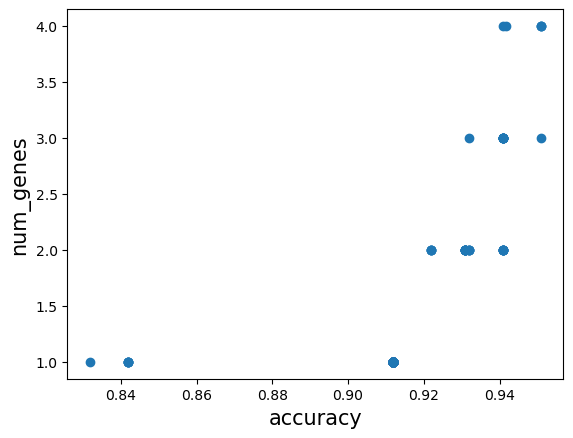

the best one is: accuracy is  0.9509090909090909 , num of genes is  3
selected genes are:  ['ARPC3' 'AES' 'APBB2']
the best one of generation 0 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9109090909090909 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9509090909090909 , num of genes is  4
the best one of generatio

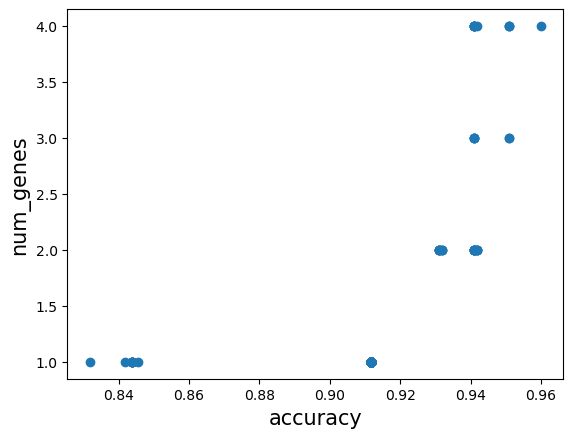

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ARPC3' 'BTRC' 'ANXA7' 'ASIC1']
the best one of generation 0 is: accuracy is  0.8927272727272728 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9027272727272727 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9209090909090909 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9209090909090909 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9209090909090909 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9209090909090909 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9318181818181819 , num of genes is  2
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  5
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  5
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  4
the best one of generation 10 is:

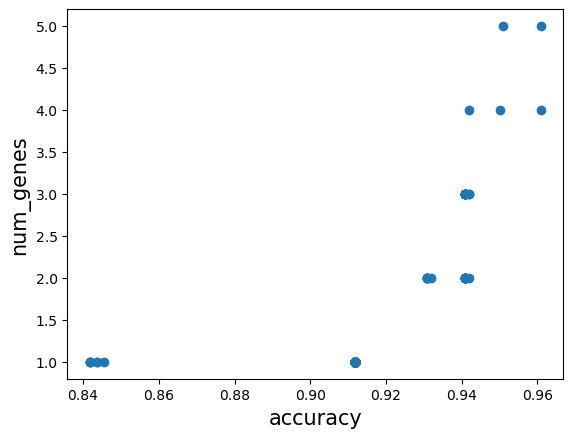

the best one is: accuracy is  0.9609090909090909 , num of genes is  4
selected genes are:  ['ARPC3' 'AFAP1' 'ANKRD40' 'CD4']
the best one of generation 0 is: accuracy is  0.8709090909090909 , num of genes is  2
the best one of generation 1 is: accuracy is  0.8709090909090909 , num of genes is  2
the best one of generation 2 is: accuracy is  0.8709090909090909 , num of genes is  2
the best one of generation 3 is: accuracy is  0.8936363636363638 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8936363636363638 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 6 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 7 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of

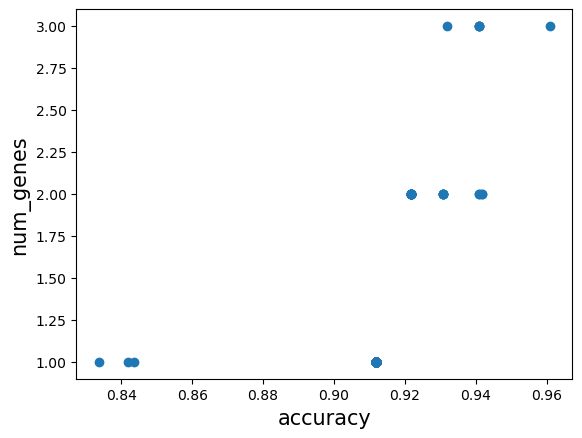

the best one is: accuracy is  0.9609090909090909 , num of genes is  3
selected genes are:  ['ARPC3' 'CHGA' 'CA1']
the best one of generation 0 is: accuracy is  0.8709090909090909 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8709090909090909 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8709090909090909 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9036363636363636 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9036363636363636 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9036363636363636 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9036363636363636 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9109090909090909 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9109090909090909 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9227272727272728 , num of genes is  4
the best one of generation

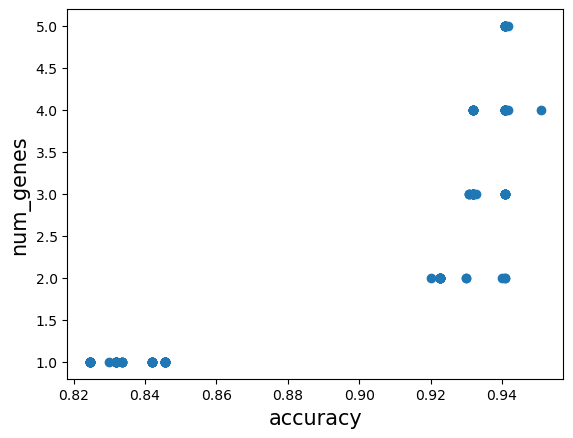

the best one is: accuracy is  0.9509090909090909 , num of genes is  4
selected genes are:  ['CDC14A' 'CAMP' 'BLCAP' 'BLZF1']
the best one of generation 0 is: accuracy is  0.840909090909091 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8699999999999999 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8709090909090909 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8709090909090909 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8809090909090909 , num of genes is  5
the best one of generation 5 is: accuracy is  0.890909090909091 , num of genes is  5
the best one of generation 6 is: accuracy is  0.900909090909091 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9018181818181817 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9100000000000001 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9100000000000001 , num of genes is  4
the best one of ge

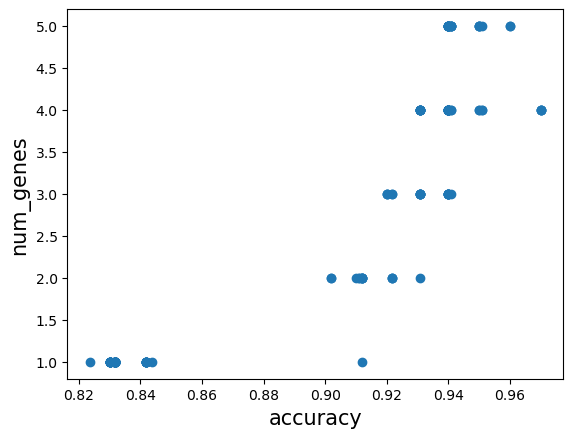

the best one is: accuracy is  0.97 , num of genes is  4
selected genes are:  ['ABTB2' 'B4GALT4' 'BASP1' 'C11orf80 ']
the best one of generation 0 is: accuracy is  0.8636363636363636 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8636363636363636 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8727272727272728 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8727272727272728 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8727272727272728 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9236363636363636 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9236363636363636 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9236363636363636 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9236363636363636 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9236363636363636 , num of genes is  4
the best one of generat

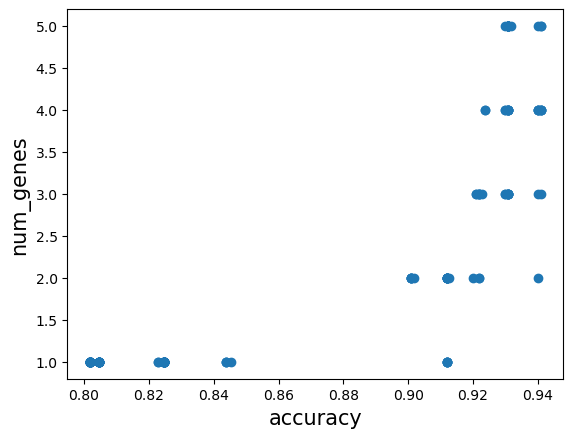

the best one is: accuracy is  0.940909090909091 , num of genes is  3
selected genes are:  ['C5orf30' 'ARPC3' 'AHSG']
the best one of generation 0 is: accuracy is  0.8536363636363637 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8536363636363637 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8536363636363637 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8536363636363637 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8718181818181818 , num of genes is  2
the best one of generation 5 is: accuracy is  0.8818181818181818 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8918181818181818 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9118181818181819 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9118181818181819 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9318181818181819 , num of genes is  4
the best one of generat

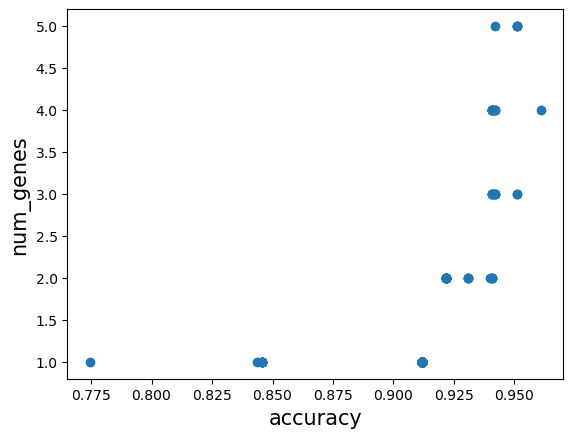

the best one is: accuracy is  0.9609090909090909 , num of genes is  4
selected genes are:  ['ARPC3' 'CDKN1B' 'ABCA6' 'CENPF']
the best one of generation 0 is: accuracy is  0.900909090909091 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  5
the best one of generation 6 is: accuracy is  0.940909090909091 , num of genes is  3
the best one of generation 7 is: accuracy is  0.940909090909091 , num of genes is  2
the best one of generation 8 is: accuracy is  0.940909090909091 , num of genes is  2
the best one of generation 9 is: accuracy is  0.940909090909091 , num of genes is  2
the best one of gen

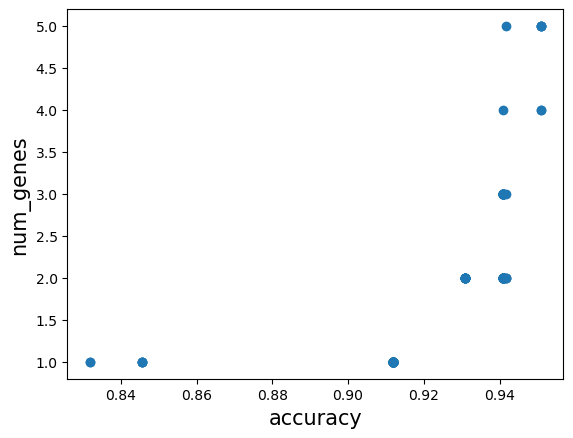

the best one is: accuracy is  0.9509090909090909 , num of genes is  4
selected genes are:  ['CAMP' 'APBB3 ' 'ATAD2B' 'C6']
the best one of generation 0 is: accuracy is  0.8709090909090909 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8709090909090909 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8718181818181818 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8718181818181818 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8718181818181818 , num of genes is  2
the best one of generation 5 is: accuracy is  0.8827272727272728 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9018181818181817 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9018181818181817 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9318181818181819 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9318181818181819 , num of genes is  3
the best one of g

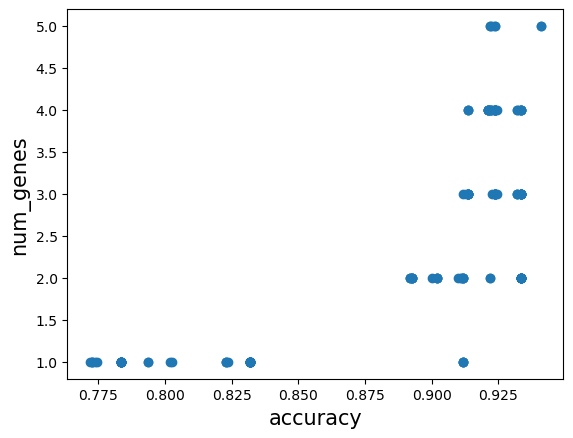

the best one is: accuracy is  0.940909090909091 , num of genes is  5
selected genes are:  ['ASCL1' 'AK055981 ' 'ARHGDIB' 'ASIP' 'ANK3']
the best one of generation 0 is: accuracy is  0.8618181818181819 , num of genes is  4
the best one of generation 1 is: accuracy is  0.901818181818182 , num of genes is  3
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  3
the best one of generation 3 is: accuracy is  0.901818181818182 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9218181818181819 , num of genes is  5
the bes

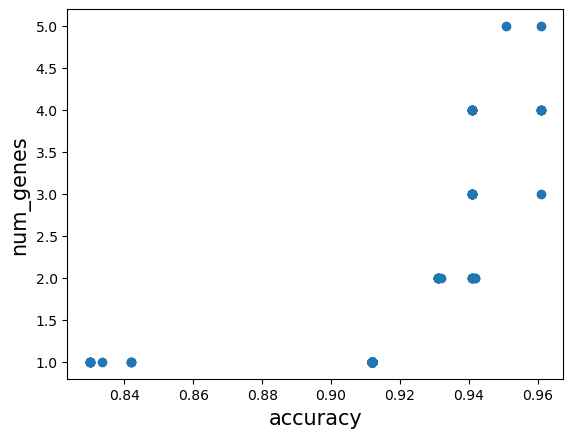

the best one is: accuracy is  0.9609090909090909 , num of genes is  3
selected genes are:  ['CD4' 'ARPC3' 'CAMP']
the best one of generation 0 is: accuracy is  0.9118181818181819 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9218181818181819 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9318181818181819 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9318181818181819 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9318181818181819 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9318181818181819 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9318181818181819 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9318181818181819 , num of genes is  4
the best one of generation

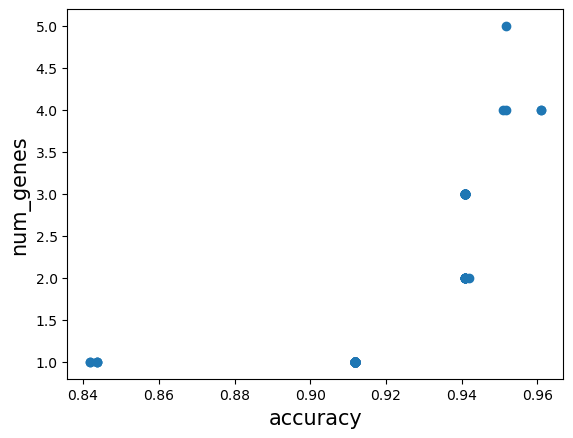

the best one is: accuracy is  0.9609090909090909 , num of genes is  4
selected genes are:  ['ARPC3' 'APBA3' 'ARIH1' 'CAMP']
the best one of generation 0 is: accuracy is  0.9027272727272727 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9027272727272727 , num of genes is  2
the best one of generation 2 is: accuracy is  0.9109090909090911 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9109090909090911 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9318181818181819 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9318181818181819 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9418181818181818 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9418181818181818 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9418181818181818 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9418181818181818 , num of genes is  2
the best one of 

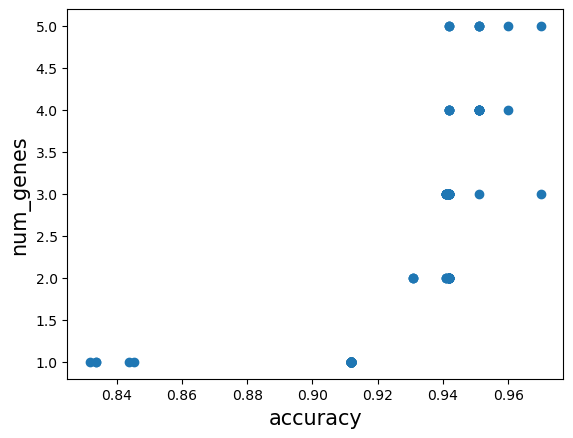

the best one is: accuracy is  0.9700000000000001 , num of genes is  3
selected genes are:  ['CD4' 'ARPC3' 'AES']
the best one of generation 0 is: accuracy is  0.8527272727272728 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8527272727272728 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8527272727272728 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8627272727272727 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8636363636363636 , num of genes is  2
the best one of generation 5 is: accuracy is  0.8818181818181821 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8927272727272726 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9118181818181817 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9118181818181817 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9118181818181817 , num of genes is  5
the best one of generation 

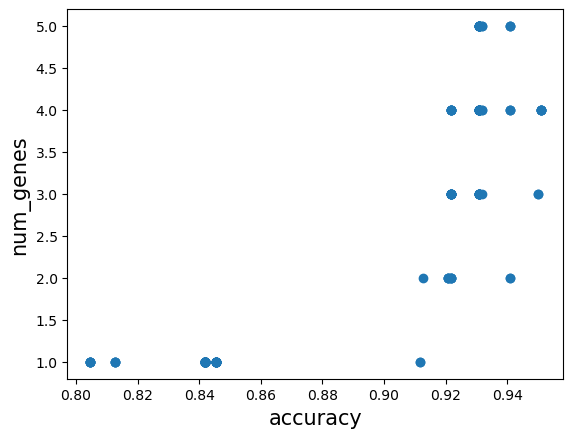

the best one is: accuracy is  0.9509090909090909 , num of genes is  4
selected genes are:  ['CD40LG' 'BAP1' 'CCNA2' 'ADCY1']
the best one of generation 0 is: accuracy is  0.8709090909090909 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9018181818181817 , num of genes is  3
the best one of generation 2 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 3 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 4 is: accuracy is  0.901818181818182 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 6 is: accuracy is  0.9118181818181819 , num of genes is  1
the best one of generation 7 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9218181818181819 , num of genes is  2
the best one of generation 9 is: accuracy is  0.95 , num of genes is  4
the best one of generation 10 is

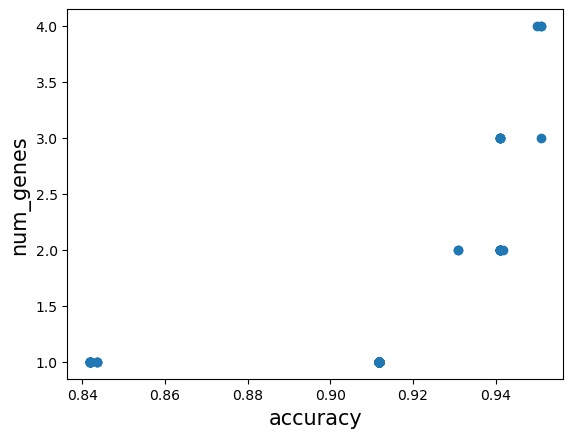

the best one is: accuracy is  0.9509090909090909 , num of genes is  3
selected genes are:  ['BLVRB' 'ANXA11' 'ACACA']


In [8]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=5,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1